# KASBench Analysis
## Download and Preprocessing

This notebook downloads the KASBench dataset from S3 and performs some basic preprocessing steps.



In [100]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [101]:
!uv add seaborn

Resolved 34 packages in 20ms
Checked 31 packages in 7ms


In [102]:
import io
import json
import os
import datetime   
import importlib
from __future__ import annotations
from dataclasses import dataclass
import shutil
import tempfile
import time
from urllib.parse import urlparse
import requests
import re


import boto3
import pandas as pd
import numpy as np
import sqlite3
import pyperclip
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from prometheus_api_client import PrometheusConnect, MetricRangeDataFrame
import docker
import seaborn as sns
sns.set_theme()


import common
importlib.reload(common)

from common import (
    get_s3_file_listing, 
    is_locust_db, 
    download_locust_db, 
    parse_locust_db_file_info,
    create_log_database,
    get_raw_log_as_dataframe,
    get_log_as_dataframe,
    get_run_details,
    get_autoscaler,
    get_trial_summary_df,
    get_autoscaler_summary,
    parse_roundtrip_file_info,
    merge_roundtrip_completion_percentage,
    calculate_theta_metrics,
    calculate_tau_metrics,
    append_time_slice,
    add_weighted_theta,
    add_weighted_tau,
    calculate_async_utilization_by_autoscaler,
    parse_run_details_file_info,
    get_run_start_and_end_times,
    get_trial_start_and_end_times,
    get_asynchronous_metrics,
    get_merged_range_metric_df,
    get_tsdb_snapshots,
    tsdb_snapshot_exists,
    get_tsdb_local_dir,
    parse_snapshot_name,
    execute_promql_range,
    parse_s3_uri,
    download_s3_folder,
    wait_for_prometheus,
    execute_promql,
    run_snapshot_analysis,
    get_metric_from_tsdb,
    plot_trial_timeseries_binned,
    plot_cpu_allocation,
    plot_cpu_saturation_time_share,
    prepare_cpu_requested_vs_usage,
    summarize_cpu_time_series,
    plot_cpu_requested_vs_usage,
    plot_cpu_reservation_gap
    )


### Get environmental variables

In [103]:
load_dotenv()
s3_bucket = os.environ.get("S3_BUCKET")
print(f"S3 Bucket: {s3_bucket}")

S3 Bucket: kasbench-test-20260528-377288663341-us-east-1-an


### Set constants and create directories

In [179]:
RUN = "verification-15-percentile-large-a"
# RUN = "run001"
DATA_DIR = f"../data/{RUN}"
os.makedirs(DATA_DIR, exist_ok=True)
RUN_DB = f"{DATA_DIR}/logs.db"
print(f"Run database is {RUN_DB}")


Run database is ../data/verification-15-percentile-large-a/logs.db


### Get the file listing from S3   

In [ ]:
files = get_s3_file_listing(s3_bucket, s3_prefix=RUN)


### Iterate the file listing and download all the Locust databases to local storage

In [ ]:
files = get_s3_file_listing(s3_bucket, s3_prefix=RUN)
# Delete the log database if it already exists
if os.path.exists(RUN_DB):
    os.remove(RUN_DB)

# Create the log database
create_log_database(RUN_DB)

# Populate the log database from the locust database files
for file_info in files:
    # skip non-database files
    if not is_locust_db(file_info):
        continue
    
    # parse trial, role, and filename from the S3 file info
    trial, role, filename = parse_locust_db_file_info(file_info)

    # get the autoscaler from the run details
    run_details = get_run_details(s3_bucket, RUN, trial)
    autoscaler = get_autoscaler(run_details)

    # skip if it-operations.  It operations transactions are not tracked for response time/failure rate
    if role == "it-operations":
        continue
    
    # download the database if it doesn't already exist
    local_path = download_locust_db(DATA_DIR, s3_bucket, file_info["Key"], trial, role, filename)
    
    # load as a dataframe, augmented with run id, trial id, and role
    df = get_raw_log_as_dataframe(local_path)
    df["run_id" ] = RUN
    df["trial_id" ] = trial
    df["role" ] = role
    df["autoscaler" ] = autoscaler
    df["success"] = (
        pd.to_numeric(df["status_code"], errors="coerce")
          .between(200, 299)
        )
    df["failure"] = ~df["success"]

    # append to the sqlite database
    df.to_sql('logs', sqlite3.connect(RUN_DB), if_exists='append', index=False)
    


    


### Load the aggregate database into a dataframe for analysis

In [319]:
df = get_log_as_dataframe(RUN_DB)
raw_df = df.copy()
df


,run_id,trial_id,role,autoscaler,user_id,request_type,name,response_time,response_length,response,status_code,reason,exception,start_time,url,method_and_name,success,failure
0,verification-15-percentile-large-a,trial0001,back-office,hpa,e126ed2a-c98f-4eae-b751-76e6c1a40357,POST,/api/portfolios/bulk,42.258767,140,<Response [201]>,201,Created,None,2026-09-18 20:48:57.079076,http://kasb-20260918203417760500000012-65e557d...,POST /api/portfolios/bulk,1,0
1,verification-15-percentile-large-a,trial0001,back-office,hpa,e126ed2a-c98f-4eae-b751-76e6c1a40357,GET,/api/portfolios/{id},14.779433,133,<Response [200]>,200,OK,None,2026-09-18 20:48:57.813457,http://kasb-20260918203417760500000012-65e557d...,GET /api/portfolios/{id},1,0
2,verification-15-percentile-large-a,trial0001,back-office,hpa,e3fa42cb-9fc8-486b-87ab-99f9bbdf1402,GET,/api/portfolios/{id},15.270038,133,<Response [200]>,200,OK,None,2026-09-18 20:48:59.020132,http://kasb-20260918203417760500000012-65e557d...,GET /api/portfolios/{id},1,0
3,verification-15-percentile-large-a,trial0001,back-office,hpa,e126ed2a-c98f-4eae-b751-76e6c1a40357,POST,/api/transactions,43.029360,344,<Response [201]>,201,Created,None,2026-09-18 20:48:59.096519,http://kasb-20260918203417760500000012-65e557d...,POST /api/transactions,1,0
4,verification-15-percentile-large-a,trial0001,back-office,hpa,8058055e-2995-4b46-866b-de3725c74930,POST,/api/portfolios/bulk,14.943686,140,<Response [201]>,201,Created,None,2026-09-18 20:49:03.800782,http://kasb-20260918203417760500000012-65e557d...,POST /api/portfolios/bulk,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4153508,verification-15-percentile-large-a,trial0016,trader,none,525d7b24-0ded-4778-86f9-b5cd620fc01c,GET,/api/executions?portfolio_id={portfolio_id},31.095608,40680,<Response [200]>,200,OK,None,2026-09-19 10:10:42.498947,http://kasb-20260919092613069300000012-b478297...,GET /api/executions?portfolio_id={portfolio_id},1,0
4153509,verification-15-percentile-large-a,trial0016,trader,none,2562d238-8bad-4043-9b6d-1ee1acbb2a79,POST,/api/trade-orders/batch/submit,19.585565,1050,<Response [200]>,200,OK,None,2026-09-19 10:10:42.516645,http://kasb-20260919092613069300000012-b478297...,POST /api/trade-orders/batch/submit,1,0
4153510,verification-15-percentile-large-a,trial0016,trader,none,2562d238-8bad-4043-9b6d-1ee1acbb2a79,GET,/api/executions/{id},15.909038,404,<Response [200]>,200,OK,None,2026-09-19 10:10:42.543520,http://kasb-20260919092613069300000012-b478297...,GET /api/executions/{id},1,0
4153511,verification-15-percentile-large-a,trial0016,trader,none,8dc5d47f-c15e-4790-910b-b3559d23ac3a,GET,/api/trades?orderId,8.301543,626,<Response [200]>,200,OK,None,2026-09-19 10:10:42.583962,http://kasb-20260919092613069300000012-b478297...,GET /api/trades?orderId,1,0


In [318]:
raw_df.columns

Index(['run_id', 'trial_id', 'role', 'autoscaler', 'user_id', 'request_type',
       'name', 'response_time', 'response_length', 'response', 'status_code',
       'reason', 'exception', 'start_time', 'url', 'method_and_name',
       'success', 'failure', 'time_slice'],
      dtype='str')

### Summarize the trials

In [255]:
trial_summary_df = get_trial_summary_df(df)
trial_summary_df

,autoscaler,trial_id,successful_requests,mean_response_time,requests,failures,failure_rate
0,hpa,trial0001,271071,100.201060,271092,21,0.000077
1,hpa,trial0002,269008,95.672312,269018,10,0.000037
2,hpa,trial0008,269770,96.238712,269791,21,0.000078
3,hpa,trial0014,270765,83.824121,270773,8,0.000030
4,keda,trial0004,263527,72.755730,263695,168,0.000637
5,keda,trial0009,271433,78.629021,271437,4,0.000015
6,keda,trial0013,263116,102.307039,263246,130,0.000494
7,keda,trial0015,270074,93.885630,270186,112,0.000415
8,none,trial0005,259238,205.079382,259293,55,0.000212
9,none,trial0007,263144,165.498561,263339,195,0.000740


### Merge Roundtrip Percentage

In [256]:
merged_trial_summary_df = merge_roundtrip_completion_percentage(files, s3_bucket, trial_summary_df)
merged_trial_summary_df


,autoscaler,trial_id,successful_requests,mean_response_time,requests,failures,failure_rate,quantity_ordered,quantity_placed,quantity_filled,roundtrip_completion_percentage
0,hpa,trial0001,271071,100.201060,271092,21,0.000077,64980770,64980770,884995,1.361934
1,hpa,trial0002,269008,95.672312,269018,10,0.000037,64818672,64818672,738144,1.138783
2,hpa,trial0008,269770,96.238712,269791,21,0.000078,60070678,60070678,678733,1.129891
3,hpa,trial0014,270765,83.824121,270773,8,0.000030,62797624,62797624,766513,1.220608
4,keda,trial0004,263527,72.755730,263695,168,0.000637,61900863,61900863,3856646,6.230359
5,keda,trial0009,271433,78.629021,271437,4,0.000015,63500796,63500796,3743858,5.895765
6,keda,trial0013,263116,102.307039,263246,130,0.000494,61274996,61274996,4149238,6.771503
7,keda,trial0015,270074,93.885630,270186,112,0.000415,64268106,64268106,4001474,6.226221
8,none,trial0005,259238,205.079382,259293,55,0.000212,60683615,60683615,1015606,1.673608
9,none,trial0007,263144,165.498561,263339,195,0.000740,61955658,61955658,635408,1.025585


In [257]:
merged_trial_summary_df.columns

Index(['autoscaler', 'trial_id', 'successful_requests', 'mean_response_time',
       'requests', 'failures', 'failure_rate', 'quantity_ordered',
       'quantity_placed', 'quantity_filled',
       'roundtrip_completion_percentage'],
      dtype='str')

### Calculate minimum sample size

#### The minimum sample size for detecting a difference in means with 80% power and 5% significance level

In [317]:
import math
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import FTestAnovaPower


def robust_solve_power(cohen_f, k_groups, alpha=0.05, power=0.80):
    """Safely solves for required N per group, guarding against solver convergence failures."""
    if np.isnan(cohen_f) or cohen_f <= 0.01:
        return float("inf")

    # If effect size is enormous (e.g., f > 2.0), sample size is trivially small
    power_calc = FTestAnovaPower()

    # If power at n=2 is already >= target power, minimum n is 2
    try:
        power_at_2 = power_calc.power(
            effect_size=cohen_f, nobs=2, k_groups=k_groups, alpha=alpha
        )
        if power_at_2 >= power:
            return 2
    except Exception:
        pass

    try:
        # Solve with widened search bounds
        n = power_calc.solve_power(
            effect_size=cohen_f,
            k_groups=k_groups,
            alpha=alpha,
            power=power,
            nobs=None,
        )
        if np.isnan(n):
            # Fallback: scan integer sample sizes directly
            for candidate_n in range(2, 500):
                p = power_calc.power(
                    effect_size=cohen_f,
                    nobs=candidate_n,
                    k_groups=k_groups,
                    alpha=alpha,
                )
                if p >= power:
                    return candidate_n
            return float("inf")
        return math.ceil(n)
    except Exception:
        return float("inf")


def analyze_metric(df, metric_col, group_col="autoscaler", alpha=0.05):
    print(f"\n{'='*55}\nANALYSIS FOR: {metric_col}\n{'='*55}")

    # Drop NaNs for the current metric
    clean_df = df.dropna(subset=[metric_col, group_col]).copy()

    # 1. Group-level split
    groups = [
        group[metric_col].to_numpy()
        for _, group in clean_df.groupby(group_col)
    ]
    group_names = [name for name, _ in clean_df.groupby(group_col)]
    k_groups = len(groups)

    # 2. Assumption Checks
    p_norm_vals = [
        stats.shapiro(g).pvalue for g in groups if len(g) >= 3
    ]
    norm_pass = (
        all(p > 0.05 for p in p_norm_vals) if p_norm_vals else False
    )

    stat_levene, p_levene = stats.levene(*groups)
    equal_var = p_levene > 0.05

    print(f"Assumption Checks:")
    print(
        f"  Shapiro-Wilk (Normality p-values): {[round(float(p), 4) for p in p_norm_vals]} -> {'OK' if norm_pass else 'Warning (non-normal)'}"
    )
    print(
        f"  Levene's Test (Homoscedasticity): stat={stat_levene:.4f}, p={p_levene:.4f} -> {'OK (Equal Var)' if equal_var else 'Warning (Heteroscedastic - Use Welch)'}"
    )

    # 3. Effect Size Estimation (from sample)
    group_means = np.array([np.mean(g) for g in groups])
    group_vars = np.array([np.var(g, ddof=1) for g in groups])
    group_ns = np.array([len(g) for g in groups])

    # Pooled SD across groups
    pooled_var = np.sum((group_ns - 1) * group_vars) / np.sum(
        group_ns - 1
    )
    pooled_sd = np.sqrt(pooled_var)

    # Cohen's f = sigma_m / pooled_sd
    sigma_m = np.std(group_means, ddof=0)
    cohen_f = sigma_m / pooled_sd if pooled_sd > 0 else 0.0

    # 4. Hypothesis Testing
    if equal_var:
        # Standard Fisher's ANOVA
        formula = f"{metric_col} ~ C({group_col})"
        model = ols(formula, data=clean_df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        f_stat = anova_table.loc[f"C({group_col})", "F"]
        p_val = anova_table.loc[f"C({group_col})", "PR(>F)"]
        test_used = "Standard One-Way ANOVA"
    else:
        # Welch's ANOVA (robust to unequal variances) via Alexander-Govern or scipy
        # stats.alexandergovern provides a robust approximation for k groups with unequal variance
        res = stats.alexandergovern(*groups)
        f_stat = res.statistic
        p_val = res.pvalue
        test_used = "Alexander-Govern (Welch-type ANOVA for unequal variances)"

    # 5. Power and Sample Size Planning
    n_needed = robust_solve_power(
        cohen_f, k_groups=k_groups, alpha=alpha, power=0.80
    )

    print(f"\nHypothesis Test ({test_used}):")
    print(f"  Test Statistic: {f_stat:.4f}")
    print(f"  p-value:        {p_val:.4e}")
    print(f"  Cohen's f:      {cohen_f:.4f}")
    print(f"  Minimum trials/autoscaler for 80% power: {n_needed}")

    # 6. Post-Hoc Pairwise Comparisons
    if p_val < alpha:
        print(f"\nSignificant difference detected (p < {alpha}).")
        if equal_var:
            print("Running Tukey's HSD (Equal variances assumed):")
            tukey = pairwise_tukeyhsd(
                endog=clean_df[metric_col],
                groups=clean_df[group_col],
                alpha=alpha,
            )
            print(tukey.summary())
        else:
            print(
                "Running Pairwise Welch t-tests with Bonferroni correction (Unequal variances):"
            )
            pairs = []
            for i in range(k_groups):
                for j in range(i + 1, k_groups):
                    stat_t, p_t = stats.ttest_ind(
                        groups[i], groups[j], equal_var=False
                    )
                    pairs.append(
                        (group_names[i], group_names[j], stat_t, p_t)
                    )

            # Bonferroni adjustment
            num_comparisons = len(pairs)
            results = []
            for g1, g2, t_val, p_raw in pairs:
                p_adj = min(p_raw * num_comparisons, 1.0)
                results.append(
                    {
                        "Group 1": g1,
                        "Group 2": g2,
                        "t-stat": round(t_val, 4),
                        "p-raw": f"{p_raw:.4e}",
                        "p-adj": f"{p_adj:.4e}",
                        "Reject H0": p_adj < alpha,
                    }
                )
            print(pd.DataFrame(results).to_string(index=False))
    else:
        print(
            f"\nMain effect not statistically significant at alpha={alpha}."
        )



analyze_metric(merged_trial_summary_df, metric_col='mean_response_time')
analyze_metric(merged_trial_summary_df, metric_col='failure_rate')
analyze_metric(merged_trial_summary_df, metric_col='roundtrip_completion_percentage')



ANALYSIS FOR: mean_response_time
Assumption Checks:
  Shapiro-Wilk (Normality p-values): [0.2596, 0.6613, 0.9369, 0.977] -> OK
  Levene's Test (Homoscedasticity): stat=3.9392, p=0.0361 -> Warning (Heteroscedastic - Use Welch)

Hypothesis Test (Alexander-Govern (Welch-type ANOVA for unequal variances)):
  Test Statistic: 15.4083
  p-value:        1.4990e-03
  Cohen's f:      2.8091
  Minimum trials/autoscaler for 80% power: 7

Significant difference detected (p < 0.05).
Running Pairwise Welch t-tests with Bonferroni correction (Unequal variances):
Group 1 Group 2  t-stat      p-raw      p-adj  Reject H0
    hpa    keda  0.9253 4.0160e-01 1.0000e+00      False
    hpa    none -6.5404 5.3807e-03 3.2284e-02       True
    hpa     vpa  4.1709 1.3435e-02 8.0610e-02      False
   keda    none -6.5678 2.5985e-03 1.5591e-02       True
   keda     vpa  1.2865 2.8105e-01 1.0000e+00      False
   none     vpa  7.6845 4.2880e-03 2.5728e-02       True

ANALYSIS FOR: failure_rate
Assumption Checks:


/Users/noahkrieger/projects/dissertation/kasbench/kasbench-analysis/.venv/lib/python3.14/site-packages/statsmodels/stats/power.py:1648: ConvergenceWarning: 
Failed to converge on a solution.
The last value evaluated by the root finder was [40.]; returning nan instead. Solver details are stored in the ``cache_fit_res`` attribute.
  return super().solve_power(
/Users/noahkrieger/projects/dissertation/kasbench/kasbench-analysis/.venv/lib/python3.14/site-packages/statsmodels/stats/power.py:1648: ConvergenceWarning: 
Failed to converge on a solution.
The last value evaluated by the root finder was [40.]; returning nan instead. Solver details are stored in the ``cache_fit_res`` attribute.
  return super().solve_power(


#### Convergence analysis (to help determine run duration)

In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

DURATIONS_MINUTES = [5, 10, 15, 20, 25, 30]

AUTOSCALER_ORDER = ["none", "hpa", "vpa", "keda"]


# ---------------------------------------------------------------------------
# Prepare data
# ---------------------------------------------------------------------------

work = df.copy()

work["start_time"] = pd.to_datetime(work["start_time"], format="mixed")

# Each trial gets its own t=0.
trial_start = (
    work.groupby(["run_id", "trial_id"])["start_time"]
    .transform("min")
)

work["elapsed_seconds"] = (
    work["start_time"] - trial_start
).dt.total_seconds()

work["elapsed_minutes"] = work["elapsed_seconds"] / 60.0

In [323]:
# ---------------------------------------------------------------------------
# Calculate cumulative metrics for each trial
# ---------------------------------------------------------------------------

records = []

group_cols = ["run_id", "trial_id", "autoscaler"]

for (run_id, trial_id, autoscaler), trial_df in work.groupby(group_cols):

    trial_df = trial_df.sort_values("start_time")

    for duration in DURATIONS_MINUTES:

        # Requests that occurred during the first N minutes of the trial.
        prefix = trial_df[
            (trial_df["elapsed_minutes"] >= 0) &
            (trial_df["elapsed_minutes"] <= duration)
        ]

        if prefix.empty:
            continue

        records.append({
            "run_id": run_id,
            "trial_id": trial_id,
            "autoscaler": autoscaler,
            "duration_minutes": duration,

            # Useful diagnostic
            "requests": len(prefix),

            # Metric 1
            "mean_response_time": prefix["response_time"].mean(),

            # Metric 2
            "failure_rate": prefix["failure"].mean(),
        })


convergence_df = pd.DataFrame(records)

convergence_df = convergence_df.sort_values(
    ["autoscaler", "run_id", "trial_id", "duration_minutes"]
).reset_index(drop=True)

convergence_df.head()

,run_id,trial_id,autoscaler,duration_minutes,requests,mean_response_time,failure_rate
0,verification-15-percentile-large-a,trial0001,hpa,5,37896,58.803088,0.000185
1,verification-15-percentile-large-a,trial0001,hpa,10,74879,55.044948,0.000093
2,verification-15-percentile-large-a,trial0001,hpa,15,130553,125.722229,0.000054
3,verification-15-percentile-large-a,trial0001,hpa,20,184816,118.206688,0.000114
4,verification-15-percentile-large-a,trial0001,hpa,25,223735,104.604216,0.000094


In [324]:
def plot_convergence(
    convergence_df,
    metric,
    ylabel,
    autoscaler_order=AUTOSCALER_ORDER,
    figsize=(10, 6),
):
    fig, ax = plt.subplots(figsize=figsize)

    autoscalers = [
        a for a in autoscaler_order
        if a in convergence_df["autoscaler"].unique()
    ]

    # One line for every independent trial.
    for autoscaler in autoscalers:

        autoscaler_df = convergence_df[
            convergence_df["autoscaler"] == autoscaler
        ]

        for (run_id, trial_id), trial_df in autoscaler_df.groupby(
            ["run_id", "trial_id"]
        ):
            trial_df = trial_df.sort_values("duration_minutes")

            ax.plot(
                trial_df["duration_minutes"],
                trial_df[metric],
                marker="o",
                alpha=0.45,
                label=autoscaler,
            )

    ax.set_xlabel("Cumulative Trial Duration (minutes)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(DURATIONS_MINUTES)
    ax.grid(True, alpha=0.25)

    # Remove duplicate legend entries.
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))

    ax.legend(
        unique.values(),
        unique.keys(),
        title="Autoscaler",
    )

    fig.tight_layout()

    return fig, ax

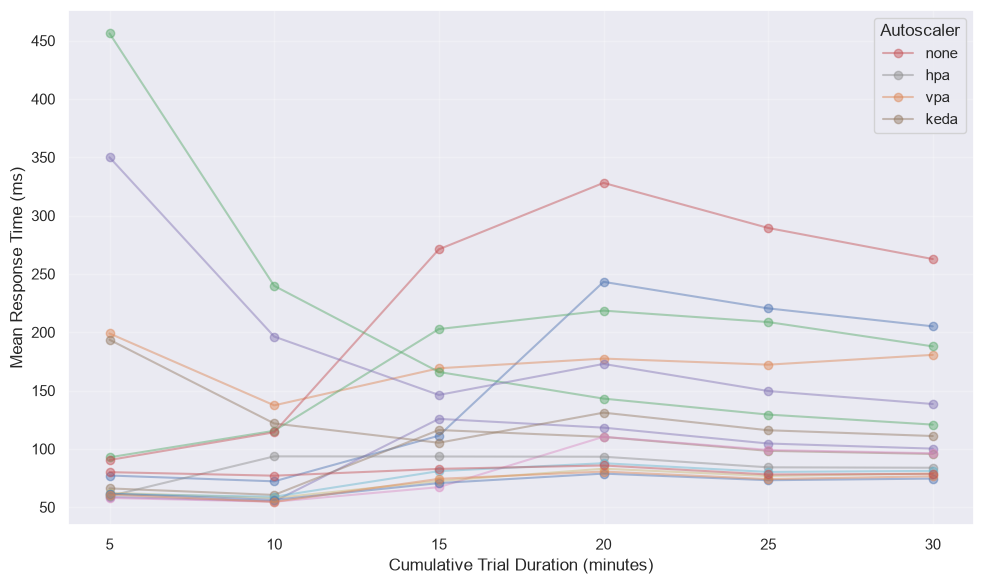

In [325]:
plot_convergence(
    convergence_df,
    metric="mean_response_time",
    ylabel="Mean Response Time (ms)",
)

plt.show()

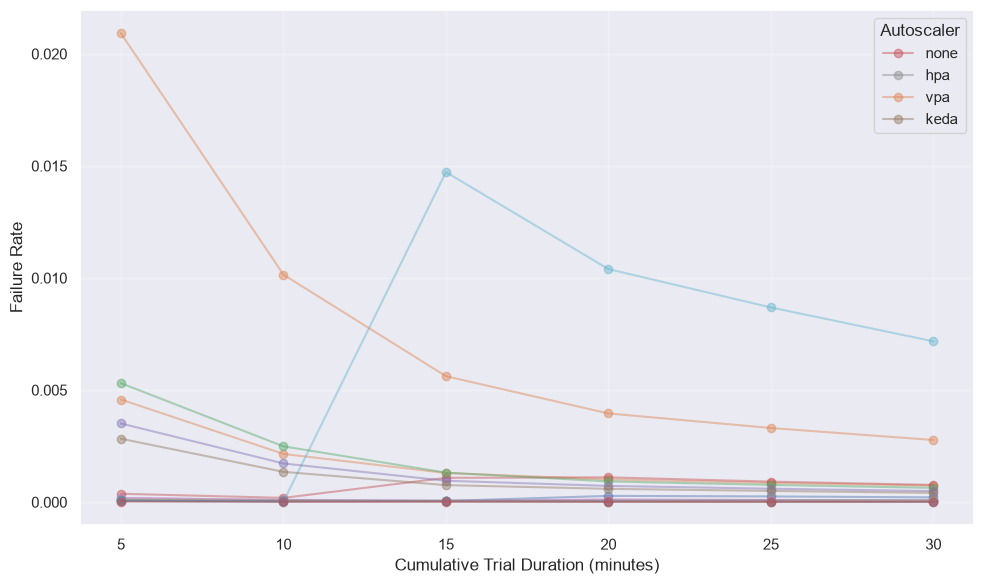

In [326]:
plot_convergence(
    convergence_df,
    metric="failure_rate",
    ylabel="Failure Rate",
)

plt.show()

In [327]:
def plot_convergence_by_autoscaler(
    convergence_df,
    metric,
    ylabel,
    autoscaler_order=AUTOSCALER_ORDER,
    figsize=(9, 5),
):
    figures = {}

    for autoscaler in autoscaler_order:

        autoscaler_df = convergence_df[
            convergence_df["autoscaler"] == autoscaler
        ]

        if autoscaler_df.empty:
            continue

        fig, ax = plt.subplots(figsize=figsize)

        for (run_id, trial_id), trial_df in autoscaler_df.groupby(
            ["run_id", "trial_id"]
        ):
            trial_df = trial_df.sort_values("duration_minutes")

            ax.plot(
                trial_df["duration_minutes"],
                trial_df[metric],
                marker="o",
                alpha=0.65,
                label=f"Trial {trial_id}",
            )

        # Autoscaler mean at each duration.
        mean_df = (
            autoscaler_df
            .groupby("duration_minutes", as_index=False)[metric]
            .mean()
        )

        ax.plot(
            mean_df["duration_minutes"],
            mean_df[metric],
            marker="o",
            linewidth=3,
            label="Mean",
        )

        ax.set_title(autoscaler.upper())
        ax.set_xlabel("Cumulative Trial Duration (minutes)")
        ax.set_ylabel(ylabel)
        ax.set_xticks(DURATIONS_MINUTES)
        ax.grid(True, alpha=0.25)
        ax.legend()

        fig.tight_layout()

        figures[autoscaler] = (fig, ax)

    return figures

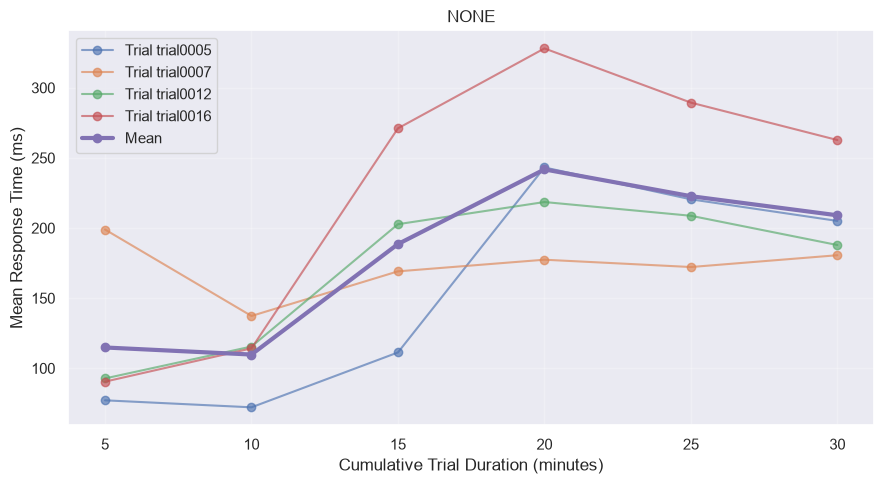

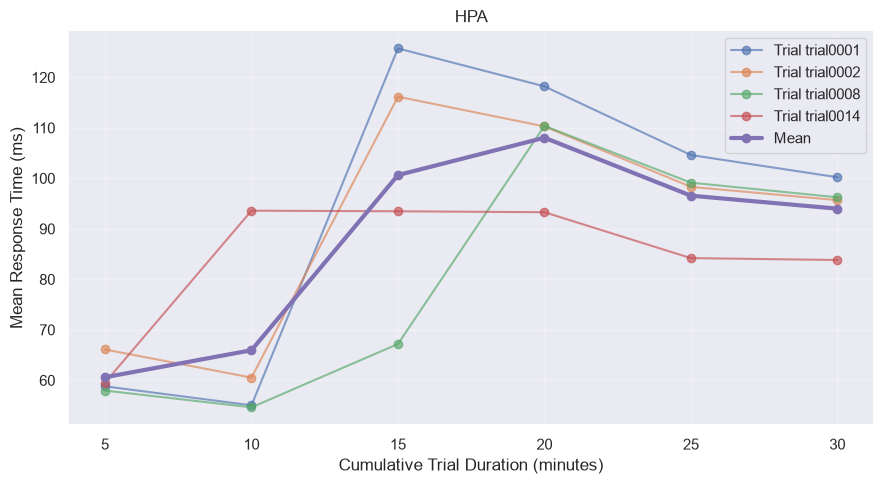

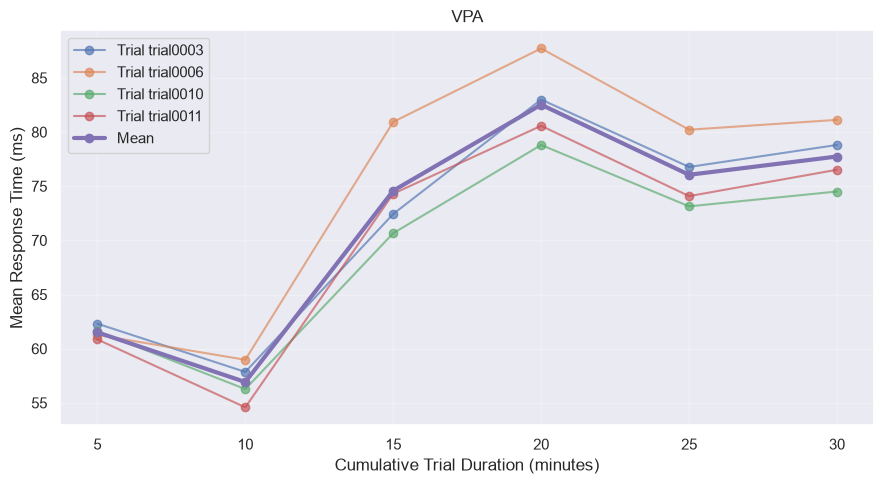

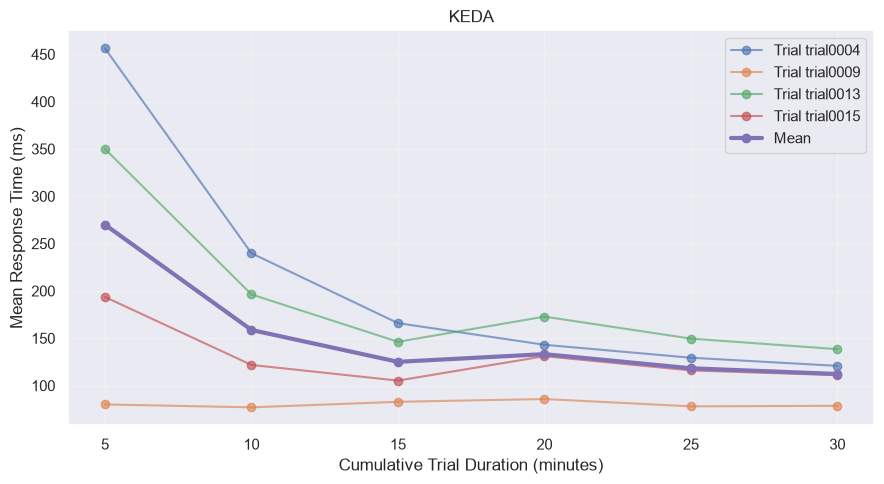

In [328]:
figures = plot_convergence_by_autoscaler(
    convergence_df,
    metric="mean_response_time",
    ylabel="Mean Response Time (ms)",
)

plt.show()

In [329]:
def calculate_convergence_error(
    convergence_df,
    metric,
    reference_duration=30,
):
    result = convergence_df.copy()

    reference = (
        result[
            result["duration_minutes"] == reference_duration
        ][
            ["run_id", "trial_id", "autoscaler", metric]
        ]
        .rename(columns={metric: "reference_value"})
    )

    result = result.merge(
        reference,
        on=["run_id", "trial_id", "autoscaler"],
        how="left",
    )

    result["absolute_difference"] = (
        result[metric] - result["reference_value"]
    ).abs()

    result["percent_difference"] = (
        100
        * result["absolute_difference"]
        / result["reference_value"].abs()
    )

    return result

In [330]:
rt_convergence = calculate_convergence_error(
    convergence_df,
    "mean_response_time",
)

fr_convergence = calculate_convergence_error(
    convergence_df,
    "failure_rate",
)

In [331]:
fr_convergence["failure_rate_difference_pp"] = (
    100
    * fr_convergence["absolute_difference"]
)

In [332]:
rt_summary = (
    rt_convergence
    .groupby(["autoscaler", "duration_minutes"])
    .agg(
        mean_percent_difference=("percent_difference", "mean"),
        median_percent_difference=("percent_difference", "median"),
        max_percent_difference=("percent_difference", "max"),
    )
    .reset_index()
)

rt_summary

,autoscaler,duration_minutes,mean_percent_difference,median_percent_difference,max_percent_difference
0,hpa,5,35.240637,35.342390,41.319349
1,hpa,10,34.167119,39.975258,45.069664
2,hpa,15,22.144675,23.438888,30.192513
3,hpa,20,14.799837,14.976405,17.960564
4,hpa,25,2.647828,2.882865,4.386414
5,hpa,30,0.000000,0.000000,0.000000
6,keda,5,126.633822,113.540533,277.636648
7,keda,10,37.999210,25.722379,98.493799
8,keda,15,13.390267,5.495180,37.364346
9,keda,20,17.601110,18.237891,24.827714


In [333]:
fr_summary = (
    fr_convergence
    .groupby(["autoscaler", "duration_minutes"])
    .agg(
        mean_difference_pp=("failure_rate_difference_pp", "mean"),
        median_difference_pp=("failure_rate_difference_pp", "median"),
        max_difference_pp=("failure_rate_difference_pp", "max"),
    )
    .reset_index()
)

fr_summary

,autoscaler,duration_minutes,mean_difference_pp,median_difference_pp,max_difference_pp
0,hpa,5,0.007665,0.009105,0.010725
1,hpa,10,0.002475,0.002227,0.005099
2,hpa,15,0.001683,0.001635,0.002385
3,hpa,20,0.002107,0.002091,0.003616
4,hpa,25,0.001046,0.001188,0.001640
5,hpa,30,0.000000,0.000000,0.000000
6,keda,5,0.252811,0.271527,0.466956
7,keda,10,0.100560,0.108466,0.185189
8,keda,15,0.037132,0.040270,0.067954
9,keda,20,0.017473,0.020501,0.028767


### Aggregate the summarized trials

In [258]:
autoscaler_summary = get_autoscaler_summary(merged_trial_summary_df)
autoscaler_summary

,autoscaler,trials,mean_rt,median_rt,sd_rt,mean_failure_rate,median_failure_rate,sd_failure_rate,mean_roundtrip_completion_percentage,median_roundtrip_completion_percentage,sd_roundtrip_completion_percentage,total_quantity_ordered,total_quantity_placed,total_quantity_filled,ci95_rt,ci95_failure_rate,ci95_roundtrip_completion_percentage,pooled_roundtrip_completion_percentage
0,hpa,4,93.984051,95.955512,7.066566,0.000056,0.000057,0.000026,1.212804,1.179696,0.107478,252667744,252667744,3068385,11.244484,0.000041,0.171021,1.214395
1,keda,4,86.894355,86.257325,13.597122,0.000390,0.000454,0.000267,6.280962,6.228290,0.362659,250944761,250944761,15751216,21.636056,0.000424,0.577071,6.276766
2,none,4,199.686586,196.485724,31.541200,0.000451,0.000476,0.000354,1.728982,1.714428,0.587391,188298323,188298323,3058287,50.189087,0.000564,0.934671,1.624171
3,vpa,4,77.930020,77.765209,3.053595,0.002502,0.001407,0.003373,2.398384,2.426019,0.139950,246840959,246840959,5919848,4.858951,0.005368,0.222692,2.398244


In [313]:
autoscaler_summary.columns

Index(['autoscaler', 'trials', 'mean_rt', 'median_rt', 'sd_rt',
       'mean_failure_rate', 'median_failure_rate', 'sd_failure_rate',
       'mean_roundtrip_completion_percentage',
       'median_roundtrip_completion_percentage',
       'sd_roundtrip_completion_percentage', 'total_quantity_ordered',
       'total_quantity_placed', 'total_quantity_filled', 'ci95_rt',
       'ci95_failure_rate', 'ci95_roundtrip_completion_percentage',
       'pooled_roundtrip_completion_percentage'],
      dtype='str')

### Visualize the results

#### Plot mean response time by autoscaler


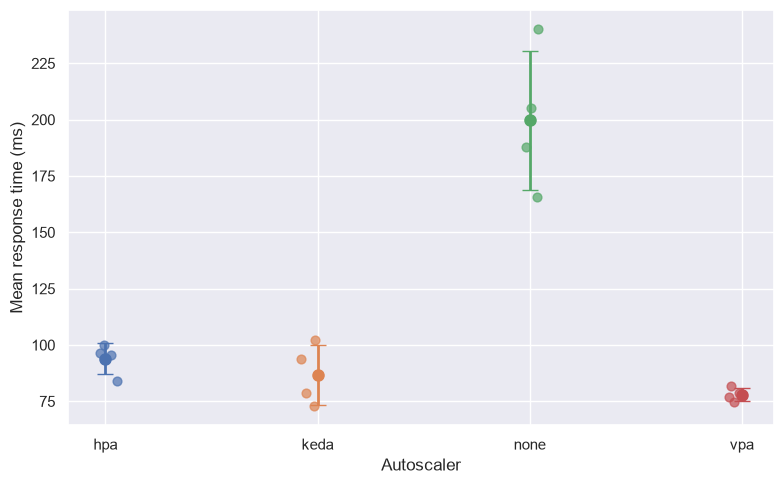

In [259]:
fig, ax = plt.subplots(figsize=(8,5))

autoscalers = sorted(merged_trial_summary_df["autoscaler"].unique())

for i, a in enumerate(autoscalers):
    d = trial_summary_df[trial_summary_df.autoscaler == a]

    # jittered trial means
    x = np.random.normal(i, 0.04, len(d))
    ax.scatter(x, d["mean_response_time"],
               alpha=0.7, s=40)

    mean = d["mean_response_time"].mean()
    se = d["mean_response_time"].std(ddof=1) / np.sqrt(len(d))

    ax.errorbar(
        i,
        mean,
        yerr=1.96 * se,
        fmt="o",
        capsize=6,
        markersize=8,
        linewidth=2,
    )

ax.set_xticks(range(len(autoscalers)))
ax.set_xticklabels(autoscalers)
ax.set_ylabel("Mean response time (ms)")
ax.set_xlabel("Autoscaler")

plt.tight_layout()

In [260]:
fig.savefig(
    "../figures/response_time_by_autoscaler.png",
    dpi=300,
    bbox_inches="tight",
)

#### Plot failure rate by autoscaler


In [261]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t


def plot_failure_rate_by_autoscaler(
    trial_summary: pd.DataFrame,
    *,
    autoscaler_order: list[str] | None = None,
    confidence_level: float = 0.95,
    random_seed: int = 42,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot trial-level failure rates by autoscaler.

    Each small point represents one trial. The larger point represents the
    unweighted mean of the trial failure rates. Error bars show a two-sided
    Student-t confidence interval for the mean.

    Parameters
    ----------
    trial_summary:
        DataFrame containing:
          - autoscaler
          - trial_id
          - failure_rate

        failure_rate must be expressed as a proportion, e.g. 0.025 for 2.5%.

    autoscaler_order:
        Optional display order. Autoscalers not listed here are appended
        alphabetically.

    confidence_level:
        Confidence level for the error bars. Default is 0.95.

    random_seed:
        Seed used to make horizontal point jitter reproducible.

    Returns
    -------
    tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]
        The generated figure and axes.
    """
    required_columns = {"autoscaler", "trial_id", "failure_rate"}
    missing_columns = required_columns - set(trial_summary.columns)

    if missing_columns:
        raise ValueError(
            f"trial_summary is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if not 0 < confidence_level < 1:
        raise ValueError("confidence_level must be between 0 and 1.")

    plot_df = trial_summary[
        ["autoscaler", "trial_id", "failure_rate"]
    ].copy()

    plot_df["failure_rate"] = pd.to_numeric(
        plot_df["failure_rate"],
        errors="coerce",
    )

    if plot_df["failure_rate"].isna().any():
        bad_rows = plot_df.loc[plot_df["failure_rate"].isna()]
        raise ValueError(
            "failure_rate contains missing or nonnumeric values. "
            f"Invalid rows:\n{bad_rows}"
        )

    if not plot_df["failure_rate"].between(0, 1).all():
        bad_rows = plot_df.loc[
            ~plot_df["failure_rate"].between(0, 1)
        ]
        raise ValueError(
            "failure_rate must be between 0 and 1. "
            f"Invalid rows:\n{bad_rows}"
        )

    present_autoscalers = sorted(
        plot_df["autoscaler"].dropna().unique()
    )

    if autoscaler_order is None:
        autoscalers = present_autoscalers
    else:
        autoscalers = [
            autoscaler
            for autoscaler in autoscaler_order
            if autoscaler in present_autoscalers
        ]

        autoscalers.extend(
            autoscaler
            for autoscaler in present_autoscalers
            if autoscaler not in autoscalers
        )

    rng = np.random.default_rng(random_seed)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    alpha = 1 - confidence_level
    summary_rows = []

    for position, autoscaler in enumerate(autoscalers):
        autoscaler_df = plot_df.loc[
            plot_df["autoscaler"] == autoscaler
        ]

        rates_percent = (
            autoscaler_df["failure_rate"].to_numpy() * 100
        )

        # Add slight horizontal jitter so overlapping trial points remain visible.
        jittered_x = rng.normal(
            loc=position,
            scale=0.045,
            size=len(rates_percent),
        )

        ax.scatter(
            jittered_x,
            rates_percent,
            s=45,
            alpha=0.65,
            label="Individual trial" if position == 0 else None,
            zorder=2,
        )

        number_of_trials = len(rates_percent)
        mean_rate = rates_percent.mean()

        if number_of_trials >= 2:
            standard_deviation = rates_percent.std(ddof=1)
            standard_error = (
                standard_deviation / np.sqrt(number_of_trials)
            )

            critical_value = t.ppf(
                1 - alpha / 2,
                df=number_of_trials - 1,
            )

            confidence_interval_half_width = (
                critical_value * standard_error
            )
        else:
            standard_deviation = np.nan
            standard_error = np.nan
            confidence_interval_half_width = np.nan

        ax.errorbar(
            position,
            mean_rate,
            yerr=confidence_interval_half_width,
            fmt="o",
            markersize=9,
            capsize=7,
            capthick=1.5,
            linewidth=2,
            label=(
                f"Mean and {confidence_level:.0%} CI"
                if position == 0
                else None
            ),
            zorder=3,
        )

        summary_rows.append(
            {
                "autoscaler": autoscaler,
                "trials": number_of_trials,
                "mean_failure_rate": mean_rate / 100,
                "sd_failure_rate": standard_deviation / 100,
                "se_failure_rate": standard_error / 100,
                "ci_lower": (
                    max(
                        0,
                        mean_rate
                        - confidence_interval_half_width,
                    )
                    / 100
                    if number_of_trials >= 2
                    else np.nan
                ),
                "ci_upper": (
                    min(
                        100,
                        mean_rate
                        + confidence_interval_half_width,
                    )
                    / 100
                    if number_of_trials >= 2
                    else np.nan
                ),
            }
        )

    ax.set_xticks(range(len(autoscalers)))
    ax.set_xticklabels(
        [autoscaler.upper() for autoscaler in autoscalers]
    )

    ax.set_xlabel("Autoscaler")
    ax.set_ylabel("Failure rate (%)")
    ax.set_title(
        "Failure Rate by Autoscaler\n"
        "Trial-level rates with mean and "
        f"{confidence_level:.0%} confidence interval"
    )

    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    fig.tight_layout()

    # The summary can be retrieved from the axes for later use if desired.
    ax.failure_rate_summary = pd.DataFrame(summary_rows)

    return fig, ax

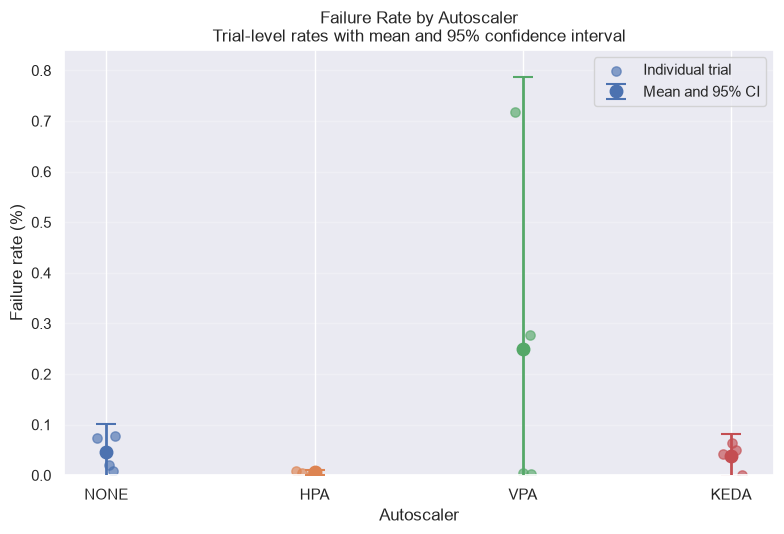

In [262]:
fig, ax = plot_failure_rate_by_autoscaler(
    merged_trial_summary_df,
    autoscaler_order=["none", "hpa", "vpa", "keda"],
)

plt.show()

In [263]:
fig.savefig(
    "../figures/failure_rate_by_autoscaler.png",
    dpi=300,
    bbox_inches="tight",
)

#### Plot of roundtrip completion percentage by autoscaler

In [264]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t


def plot_roundtrip_completion_by_autoscaler(
    trial_summary: pd.DataFrame,
    *,
    autoscaler_order: list[str] | None = None,
    confidence_level: float = 0.95,
    random_seed: int = 42,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot trial-level round-trip completion percentages by autoscaler.

    Each small point represents one trial. The larger point represents the
    unweighted mean of the trial percentages. Error bars show a two-sided
    Student-t confidence interval for the mean.

    Parameters
    ----------
    trial_summary:
        DataFrame containing:
          - autoscaler
          - trial_id
          - roundtrip_completion_percentage

        roundtrip_completion_percentage must be expressed in percentage
        points, such as 9.3 for 9.3%, rather than 0.093.

    autoscaler_order:
        Optional display order. Autoscalers present in the dataframe but not
        listed here are appended alphabetically.

    confidence_level:
        Confidence level for the error bars. Defaults to 0.95.

    random_seed:
        Seed used to make the horizontal jitter reproducible.

    Returns
    -------
    tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]
        The generated figure and axes.
    """
    required_columns = {
        "autoscaler",
        "trial_id",
        "roundtrip_completion_percentage",
    }
    missing_columns = required_columns - set(trial_summary.columns)

    if missing_columns:
        raise ValueError(
            "trial_summary is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if not 0 < confidence_level < 1:
        raise ValueError("confidence_level must be between 0 and 1.")

    plot_df = trial_summary[
        [
            "autoscaler",
            "trial_id",
            "roundtrip_completion_percentage",
        ]
    ].copy()

    if plot_df["autoscaler"].isna().any():
        raise ValueError("autoscaler contains missing values.")

    if plot_df["trial_id"].isna().any():
        raise ValueError("trial_id contains missing values.")

    plot_df["roundtrip_completion_percentage"] = pd.to_numeric(
        plot_df["roundtrip_completion_percentage"],
        errors="coerce",
    )

    if plot_df["roundtrip_completion_percentage"].isna().any():
        bad_rows = plot_df.loc[
            plot_df["roundtrip_completion_percentage"].isna()
        ]
        raise ValueError(
            "roundtrip_completion_percentage contains missing or "
            f"nonnumeric values:\n{bad_rows}"
        )

    if not plot_df["roundtrip_completion_percentage"].between(
        0, 100
    ).all():
        bad_rows = plot_df.loc[
            ~plot_df["roundtrip_completion_percentage"].between(0, 100)
        ]
        raise ValueError(
            "roundtrip_completion_percentage must be between 0 and 100. "
            f"Invalid rows:\n{bad_rows}"
        )

    # Prevent a trial from being counted more than once for an autoscaler.
    duplicate_mask = plot_df.duplicated(
        subset=["autoscaler", "trial_id"],
        keep=False,
    )

    if duplicate_mask.any():
        duplicate_rows = plot_df.loc[
            duplicate_mask,
            ["autoscaler", "trial_id"],
        ].sort_values(["autoscaler", "trial_id"])

        raise ValueError(
            "Each autoscaler/trial_id combination must appear exactly once. "
            f"Duplicate rows:\n{duplicate_rows}"
        )

    present_autoscalers = sorted(
        plot_df["autoscaler"].astype(str).unique()
    )

    if autoscaler_order is None:
        autoscalers = present_autoscalers
    else:
        autoscalers = [
            autoscaler
            for autoscaler in autoscaler_order
            if autoscaler in present_autoscalers
        ]

        autoscalers.extend(
            autoscaler
            for autoscaler in present_autoscalers
            if autoscaler not in autoscalers
        )

    if not autoscalers:
        raise ValueError("No autoscaler data is available to plot.")

    rng = np.random.default_rng(random_seed)
    alpha = 1 - confidence_level

    fig, ax = plt.subplots(figsize=(8, 5.5))

    summary_rows: list[dict[str, float | int | str]] = []

    for position, autoscaler in enumerate(autoscalers):
        autoscaler_df = plot_df.loc[
            plot_df["autoscaler"] == autoscaler
        ].sort_values("trial_id")

        percentages = autoscaler_df[
            "roundtrip_completion_percentage"
        ].to_numpy(dtype=float)

        number_of_trials = len(percentages)

        # Slight horizontal jitter keeps overlapping trial points visible.
        jittered_x = rng.normal(
            loc=position,
            scale=0.045,
            size=number_of_trials,
        )

        ax.scatter(
            jittered_x,
            percentages,
            s=45,
            alpha=0.65,
            label="Individual trial" if position == 0 else None,
            zorder=2,
        )

        mean_percentage = percentages.mean()

        if number_of_trials >= 2:
            standard_deviation = percentages.std(ddof=1)
            standard_error = (
                standard_deviation / np.sqrt(number_of_trials)
            )

            critical_value = t.ppf(
                1 - alpha / 2,
                df=number_of_trials - 1,
            )

            confidence_interval_half_width = (
                critical_value * standard_error
            )

            confidence_interval_lower = max(
                0.0,
                mean_percentage - confidence_interval_half_width,
            )
            confidence_interval_upper = min(
                100.0,
                mean_percentage + confidence_interval_half_width,
            )

            # Asymmetric errors allow confidence bounds to be clipped to
            # the logically valid 0%-100% interval.
            lower_error = mean_percentage - confidence_interval_lower
            upper_error = confidence_interval_upper - mean_percentage
            yerr = np.array([[lower_error], [upper_error]])
        else:
            standard_deviation = np.nan
            standard_error = np.nan
            critical_value = np.nan
            confidence_interval_half_width = np.nan
            confidence_interval_lower = np.nan
            confidence_interval_upper = np.nan
            yerr = None

        ax.errorbar(
            position,
            mean_percentage,
            yerr=yerr,
            fmt="o",
            markersize=9,
            capsize=7,
            capthick=1.5,
            linewidth=2,
            label=(
                f"Mean and {confidence_level:.0%} CI"
                if position == 0
                else None
            ),
            zorder=3,
        )

        summary_rows.append(
            {
                "autoscaler": autoscaler,
                "trials": number_of_trials,
                "mean_roundtrip_completion_percentage": mean_percentage,
                "sd_roundtrip_completion_percentage": standard_deviation,
                "se_roundtrip_completion_percentage": standard_error,
                "t_critical": critical_value,
                "ci_half_width": confidence_interval_half_width,
                "ci_lower": confidence_interval_lower,
                "ci_upper": confidence_interval_upper,
            }
        )

    ax.set_xticks(range(len(autoscalers)))
    ax.set_xticklabels(
        [autoscaler.upper() for autoscaler in autoscalers]
    )

    ax.set_xlabel("Autoscaler")
    ax.set_ylabel("Round-trip completion percentage (%)")
    ax.set_title(
        "Round-Trip Completion by Autoscaler\n"
        "Trial-level percentages with mean and "
        f"{confidence_level:.0%} confidence interval"
    )

    # Start at zero because the metric has a meaningful zero.
    # Let Matplotlib choose the upper bound unless the values approach 100%.
    ax.set_ylim(bottom=0)

    ax.grid(
        axis="y",
        alpha=0.25,
    )
    ax.legend()

    fig.tight_layout()

    # Attach the statistics used in the chart for convenient retrieval.
    ax.roundtrip_completion_summary = pd.DataFrame(summary_rows)

    return fig, ax

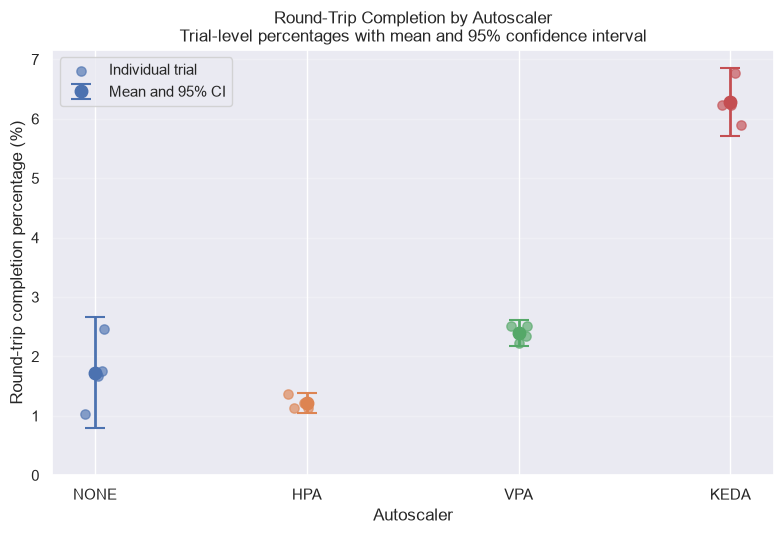

In [265]:
fig, ax = plot_roundtrip_completion_by_autoscaler(
    merged_trial_summary_df,
    autoscaler_order=["none", "hpa", "vpa", "keda"],
)

plt.show()

In [266]:
fig.savefig(
    "../figures/roundtrip_completion_by_autoscaler.png",
    dpi=300,
    bbox_inches="tight",
)

## Get benchmark starting and ending time

In [267]:
earliest_start_time, latest_end_time = get_run_start_and_end_times(files, s3_bucket, RUN)
print(f"Earliest start time: {earliest_start_time}")
print(f"Latest end time: {latest_end_time}")

Earliest start time: 2026-09-18 20:48:48.765649+00:00
Latest end time: 2026-09-19 10:10:42.345000+00:00


## Calculate synchronous $\theta$

In [268]:
TIME_SLICE_SECONDS = 30
raw_df = df.copy()
display(raw_df)
raw_df = append_time_slice(raw_df, earliest_start_time, latest_end_time, time_slice_seconds=TIME_SLICE_SECONDS)
theta_results = calculate_theta_metrics(raw_df, slo_rt_ms=150)
weighted_theta_results = add_weighted_theta(
    theta_results.autoscalers,
    gamma=0.50,
    omega=0.50,
)
weighted_theta_results




,run_id,trial_id,role,autoscaler,user_id,request_type,name,response_time,response_length,response,status_code,reason,exception,start_time,url,method_and_name,success,failure
0,verification-15-percentile-large-a,trial0001,back-office,hpa,e126ed2a-c98f-4eae-b751-76e6c1a40357,POST,/api/portfolios/bulk,42.258767,140,<Response [201]>,201,Created,None,2026-09-18 20:48:57.079076,http://kasb-20260918203417760500000012-65e557d...,POST /api/portfolios/bulk,1,0
1,verification-15-percentile-large-a,trial0001,back-office,hpa,e126ed2a-c98f-4eae-b751-76e6c1a40357,GET,/api/portfolios/{id},14.779433,133,<Response [200]>,200,OK,None,2026-09-18 20:48:57.813457,http://kasb-20260918203417760500000012-65e557d...,GET /api/portfolios/{id},1,0
2,verification-15-percentile-large-a,trial0001,back-office,hpa,e3fa42cb-9fc8-486b-87ab-99f9bbdf1402,GET,/api/portfolios/{id},15.270038,133,<Response [200]>,200,OK,None,2026-09-18 20:48:59.020132,http://kasb-20260918203417760500000012-65e557d...,GET /api/portfolios/{id},1,0
3,verification-15-percentile-large-a,trial0001,back-office,hpa,e126ed2a-c98f-4eae-b751-76e6c1a40357,POST,/api/transactions,43.029360,344,<Response [201]>,201,Created,None,2026-09-18 20:48:59.096519,http://kasb-20260918203417760500000012-65e557d...,POST /api/transactions,1,0
4,verification-15-percentile-large-a,trial0001,back-office,hpa,8058055e-2995-4b46-866b-de3725c74930,POST,/api/portfolios/bulk,14.943686,140,<Response [201]>,201,Created,None,2026-09-18 20:49:03.800782,http://kasb-20260918203417760500000012-65e557d...,POST /api/portfolios/bulk,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4153508,verification-15-percentile-large-a,trial0016,trader,none,525d7b24-0ded-4778-86f9-b5cd620fc01c,GET,/api/executions?portfolio_id={portfolio_id},31.095608,40680,<Response [200]>,200,OK,None,2026-09-19 10:10:42.498947,http://kasb-20260919092613069300000012-b478297...,GET /api/executions?portfolio_id={portfolio_id},1,0
4153509,verification-15-percentile-large-a,trial0016,trader,none,2562d238-8bad-4043-9b6d-1ee1acbb2a79,POST,/api/trade-orders/batch/submit,19.585565,1050,<Response [200]>,200,OK,None,2026-09-19 10:10:42.516645,http://kasb-20260919092613069300000012-b478297...,POST /api/trade-orders/batch/submit,1,0
4153510,verification-15-percentile-large-a,trial0016,trader,none,2562d238-8bad-4043-9b6d-1ee1acbb2a79,GET,/api/executions/{id},15.909038,404,<Response [200]>,200,OK,None,2026-09-19 10:10:42.543520,http://kasb-20260919092613069300000012-b478297...,GET /api/executions/{id},1,0
4153511,verification-15-percentile-large-a,trial0016,trader,none,8dc5d47f-c15e-4790-910b-b3559d23ac3a,GET,/api/trades?orderId,8.301543,626,<Response [200]>,200,OK,None,2026-09-19 10:10:42.583962,http://kasb-20260919092613069300000012-b478297...,GET /api/trades?orderId,1,0


,autoscaler,theta_u_rt_mean,theta_u_rt_std,theta_u_rt_count,theta_o_rt_mean,theta_o_rt_std,theta_o_rt_count,theta_u_fr_mean,theta_u_fr_std,theta_u_fr_count,theta_o_fr_mean,theta_o_fr_std,theta_o_fr_count,theta_u_rt_sem,theta_o_rt_sem,theta_u_fr_sem,theta_o_fr_sem,theta_rt_mean,theta_fr_mean,theta_mean
0,hpa,0.000000,0.000000,4,37.342727,4.713063,4,0.0,0.0,4,99.444951,0.257617,4,0.000000,2.356532,0.0,0.128808,18.671363,49.722475,34.196919
1,keda,0.000000,0.000000,4,25.179548,16.742343,4,0.0,0.0,4,96.099500,2.666235,4,0.000000,8.371171,0.0,1.333118,12.589774,48.049750,30.319762
2,none,39.383147,24.811283,4,0.000000,0.000000,4,0.0,0.0,4,95.492397,3.542772,4,12.405642,0.000000,0.0,1.771386,19.691573,47.746198,33.718886
3,vpa,0.000000,0.000000,4,48.172547,1.906114,4,0.0,0.0,4,74.981516,33.733676,4,0.000000,0.953057,0.0,16.866838,24.086273,37.490758,30.788516


## Calculate synchronous $\tau$

In [269]:
TIME_SLICE_SECONDS = 30
raw_df = df.copy()

raw_df = append_time_slice(raw_df, earliest_start_time, latest_end_time, time_slice_seconds=TIME_SLICE_SECONDS)
tau_results = calculate_tau_metrics(raw_df, slo_rt_ms=150)
weighted_tau_results = add_weighted_tau(
    tau_results.autoscalers,
    gamma=0.50,
    omega=0.50,
)
weighted_tau_results



,autoscaler,tau_u_rt_mean,tau_u_rt_std,tau_u_rt_count,tau_o_rt_mean,tau_o_rt_std,tau_o_rt_count,tau_u_fr_mean,tau_u_fr_std,tau_u_fr_count,tau_o_fr_mean,tau_o_fr_std,tau_o_fr_count,tau_u_rt_sem,tau_o_rt_sem,tau_u_fr_sem,tau_o_fr_sem,tau_rt_mean,tau_fr_mean,tau_mean
0,hpa,0.0,0.0,4,100.0,0.000000,4,0.0,0.0,4,100.0,0.0,4,0.0,0.000000,0.0,0.0,50.0,50.0,50.0
1,keda,0.0,0.0,4,50.0,57.735027,4,0.0,0.0,4,100.0,0.0,4,0.0,28.867513,0.0,0.0,25.0,50.0,37.5
2,none,100.0,0.0,4,0.0,0.000000,4,0.0,0.0,4,100.0,0.0,4,0.0,0.000000,0.0,0.0,50.0,50.0,50.0
3,vpa,0.0,0.0,4,100.0,0.000000,4,0.0,0.0,4,100.0,0.0,4,0.0,0.000000,0.0,0.0,50.0,50.0,50.0


## Calculate asynchronous $\theta$ and $\tau$

Metrics: kafka_consumer_group_lag_sum_ratio, kube_deployment_status_replicas-deployment, kafka_consumer_processing_seconds_total-service_name-topic, kafka_consumer_idle_seconds_total-service_name-topic

In [270]:
lag_df, agg_df = get_asynchronous_metrics(files, RUN, s3_bucket, earliest_start_time, latest_end_time,
    l_max=20, l_target=10, n_min=0, u_target=0.50, gamma=0.50, omega=0.50, time_slice_seconds=15)

kafka_consumer_idle_seconds_total-service_name-topic idle
kafka_consumer_processing_seconds_total-service_name-topic processing
Displaying lag_df


,timestamp,topic,autoscaler,trial_id,lag,deployment,replicas,service_name,time_slice,idle,processing,u_t
0,2026-09-18 20:52:18.766000+00:00,orders,hpa,trial0001,2985.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-09-18 20:52:18.765649+00:00, 2026-09-18 ...",0.094251,0.038690,0.291034
1,2026-09-18 20:52:33.766000+00:00,orders,hpa,trial0001,2985.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-09-18 20:52:33.765649+00:00, 2026-09-18 ...",0.102028,0.038921,0.276136
2,2026-09-18 20:52:48.766000+00:00,orders,hpa,trial0001,3622.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-09-18 20:52:48.765649+00:00, 2026-09-18 ...",0.104363,0.046550,0.308456
3,2026-09-18 20:53:03.766000+00:00,orders,hpa,trial0001,3622.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-09-18 20:53:03.765649+00:00, 2026-09-18 ...",0.104363,0.046550,0.308456
4,2026-09-18 20:53:18.766000+00:00,orders,hpa,trial0001,4373.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-09-18 20:53:18.765649+00:00, 2026-09-18 ...",0.099924,0.048483,0.326689
...,...,...,...,...,...,...,...,...,...,...,...,...
7175,2026-09-19 10:09:37.052000+00:00,fills,none,trial0016,0.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-09-19 10:09:33.765649+00:00, 2026-09-19 ...",1.005853,0.140761,0.122763
7176,2026-09-19 10:09:52.052000+00:00,fills,none,trial0016,0.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-09-19 10:09:48.765649+00:00, 2026-09-19 ...",1.005853,0.140761,0.122763
7177,2026-09-19 10:10:07.052000+00:00,fills,none,trial0016,0.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-09-19 10:10:03.765649+00:00, 2026-09-19 ...",1.005923,0.189912,0.158812
7178,2026-09-19 10:10:22.052000+00:00,fills,none,trial0016,0.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-09-19 10:10:18.765649+00:00, 2026-09-19 ...",1.005923,0.189912,0.158812


In [271]:
# with pd.option_context('display.max_rows', None):
#     display(lag_df[(lag_df.autoscaler=="keda") & (lag_df.topic=="orders") 
#         & (lag_df.deployment=="globeco-fix-engine")
#         & (lag_df.trial_id=="trial0001")])

In [272]:
# with pd.option_context('display.max_rows', None):
#     display(
#         lag_df[(lag_df.autoscaler=="hpa") & 
#         (lag_df.topic=="fills") &
#         (lag_df.deployment=="globeco-confirmation-engine") &
#         (lag_df.trial_id=="trial0016")])

In [273]:
agg_df

,autoscaler,lag_mean,theta_a_u,theta_a_o,tau_a_u,tau_a_o,theta_a,tau_a
0,hpa,6869.873557,34297.107390,41.927891,49.595843,6.870670,17169.517641,28.233256
1,keda,50.194897,207.934311,43.332266,23.832790,19.272530,125.633288,21.552660
2,none,3850.518203,19203.057452,42.592950,46.416382,13.879408,9622.825201,30.147895
3,vpa,184.418831,878.195346,52.766367,36.255411,7.792208,465.480857,22.023810


## Calculate $\bar{C}$

In [274]:
TOTAL_CPU = 16
TOTAL_MEMORY = 32

# calculate_c_bar(files, RUN, s3_bucket, TOTAL_CPU, TOTAL_MEMORY, earliest_start_time, latest_end_time)


In [275]:
metric = "kube_pod_container_resource_requests-container,cpu"
column_label = "cores"
cpu_requests_original_df = get_merged_range_metric_df(files, RUN, s3_bucket, metric, column_label)
display(cpu_requests_original_df)
# metric = "kube_pod_container_resource_limits-container,cpu"
# cpu_limits_original_df = get_merged_range_metric_df(files, RUN, s3_bucket, metric, column_label)

# joined = cpu_requests_original_df.merge(cpu_limits_original_df, on=["timestamp", "autoscaler", "trial_id", "container"], suffixes=["_requests", "_limits"]) 
# joined[joined.cores_requests != joined.cores_limits]
# joined[(joined.cores_requests != joined.cores_limits) & (joined.autoscaler == "none")].container.unique()



,timestamp,container,cores,trial_id,autoscaler
0,2026-09-18 20:48:48.766000032,envoy,0.10,trial0001,hpa
1,2026-09-18 20:49:03.766000032,envoy,0.10,trial0001,hpa
2,2026-09-18 20:49:18.766000032,envoy,0.10,trial0001,hpa
3,2026-09-18 20:49:33.766000032,envoy,0.10,trial0001,hpa
4,2026-09-18 20:49:48.766000032,envoy,0.10,trial0001,hpa
...,...,...,...,...,...
45147,2026-09-19 10:09:37.052000046,shutdown-manager,0.01,trial0016,none
45148,2026-09-19 10:09:52.052000046,shutdown-manager,0.01,trial0016,none
45149,2026-09-19 10:10:07.052000046,shutdown-manager,0.01,trial0016,none
45150,2026-09-19 10:10:22.052000046,shutdown-manager,0.01,trial0016,none


In [276]:
metric = "kube_pod_container_resource_requests-container,memory"
column_label = "bytes"
memory_requests_original_df = get_merged_range_metric_df(files, RUN, s3_bucket, metric, column_label)
display(memory_requests_original_df)
# metric = "kube_pod_container_resource_limits-container,memory"
# memory_limits_original_df = get_merged_range_metric_df(files, RUN, s3_bucket, metric, column_label)

# joined = memory_requests_original_df.merge(memory_limits_original_df, on=["timestamp", "autoscaler", "trial_id", "container"], suffixes=["_requests", "_limits"])
# joined[joined.bytes_requests != joined.bytes_limits]
# joined[joined.bytes_requests != joined.bytes_limits].container.unique()

,timestamp,container,bytes,trial_id,autoscaler
0,2026-09-18 20:48:48.766000032,envoy,536870912.0,trial0001,hpa
1,2026-09-18 20:49:03.766000032,envoy,536870912.0,trial0001,hpa
2,2026-09-18 20:49:18.766000032,envoy,536870912.0,trial0001,hpa
3,2026-09-18 20:49:33.766000032,envoy,536870912.0,trial0001,hpa
4,2026-09-18 20:49:48.766000032,envoy,536870912.0,trial0001,hpa
...,...,...,...,...,...
45147,2026-09-19 10:09:37.052000046,shutdown-manager,33554432.0,trial0016,none
45148,2026-09-19 10:09:52.052000046,shutdown-manager,33554432.0,trial0016,none
45149,2026-09-19 10:10:07.052000046,shutdown-manager,33554432.0,trial0016,none
45150,2026-09-19 10:10:22.052000046,shutdown-manager,33554432.0,trial0016,none


In [277]:
earliest_start_time, latest_end_time, TIME_SLICE_SECONDS

(datetime.datetime(2026, 9, 18, 20, 48, 48, 765649, tzinfo=datetime.timezone.utc),
 datetime.datetime(2026, 9, 19, 10, 10, 42, 345000, tzinfo=datetime.timezone.utc),
 30)

In [278]:
TIME_SLICE_SECONDS=15
ALPHA = 0.50
# join cpu_requests_original_df and memory_requests_original_df on timestamp, autoscaler, trial_id, container
c_bar_df = cpu_requests_original_df.merge(memory_requests_original_df, on=["timestamp", "autoscaler", "trial_id", "container"], suffixes=["_cpu", "_memory"])

# Convert timestamp to UTC 
c_bar_df["timestamp"] = pd.to_datetime(c_bar_df["timestamp"], unit="s", utc=True).astype('datetime64[us, UTC]')
    

# Calculate interval_range from the ealiest to latest start time
time_slice_index = pd.interval_range(
    start=earliest_start_time, 
    end=latest_end_time,
    freq=pd.Timedelta(seconds=TIME_SLICE_SECONDS),
    name="time_slice",
)


# Assign each row to a time slice based on start_time
c_bar_df["time_slice"] = pd.cut(
    c_bar_df.timestamp,
    bins=time_slice_index,
    include_lowest=True, 
    labels=time_slice_index[:],
)

# display(c_bar_df[c_bar_df.container=="globeco-order-service"])

# Calculate the mean of cores and bytes for each time_slice, autoscaler, and trial_id
c_bar_df = c_bar_df.groupby(["time_slice", "autoscaler", "trial_id"]).agg(
    cores=("cores", "mean"),
    bytes=("bytes", "mean")
).reset_index()

c_bar_df

# Calculate the mean of cores and bytes for each autoscaler
c_bar_df = c_bar_df.groupby(["autoscaler"]).agg(
    c_bar_cpu=("cores", "mean"),
    c_bar_mem=("bytes", "mean")
).reset_index()

# Convert bytes to GB
c_bar_df["c_bar_mem"] = c_bar_df["c_bar_mem"] / (1024**3)

# Calulate c_bar as ALPHA * c_bar_cpu + (1 - ALPHA) * c_bar_bytes
c_bar_df["c_bar"] = ALPHA * c_bar_df["c_bar_cpu"] + (1 - ALPHA) * c_bar_df["c_bar_mem"]

c_bar_df


,autoscaler,c_bar_cpu,c_bar_mem,c_bar
0,hpa,0.595617,0.956485,0.776051
1,keda,0.636980,1.016686,0.826833
2,none,0.384428,0.621540,0.502984
3,vpa,0.551602,0.887602,0.719602


# Analyze scaling (Horizontal)

kube_deployment_status_replicas_available

## Figure per autoscaler and pod

In [279]:
metric = "kube_deployment_status_replicas_available"
column_label = "replicas"
deployment_status_df = get_merged_range_metric_df(files, RUN, s3_bucket, metric, column_label)
display(deployment_status_df)

,timestamp,deployment,replicas,trial_id,autoscaler
0,2026-09-18 20:48:48.766000032,envoy-gateway,1.0,trial0001,hpa
1,2026-09-18 20:49:03.766000032,envoy-gateway,1.0,trial0001,hpa
2,2026-09-18 20:49:18.766000032,envoy-gateway,1.0,trial0001,hpa
3,2026-09-18 20:49:33.766000032,envoy-gateway,1.0,trial0001,hpa
4,2026-09-18 20:49:48.766000032,envoy-gateway,1.0,trial0001,hpa
...,...,...,...,...,...
30971,2026-09-19 10:09:37.052000046,otel-collector,1.0,trial0016,none
30972,2026-09-19 10:09:52.052000046,otel-collector,1.0,trial0016,none
30973,2026-09-19 10:10:07.052000046,otel-collector,1.0,trial0016,none
30974,2026-09-19 10:10:22.052000046,otel-collector,1.0,trial0016,none


In [280]:
# Re-baseline each trial so that each trial's timestamp starts at 0
deployment_status_df["timestamp"] = deployment_status_df["timestamp"] - deployment_status_df.groupby(["trial_id"])["timestamp"].transform("min")

# Group deployment_status_df by autoscaler
deployment_status_agg_df = deployment_status_df.groupby(["timestamp","deployment", "autoscaler"]).agg(
    replicas=("replicas", "mean")
).reset_index()

# Exclude non-globeco pods
deployment_status_agg_df = deployment_status_agg_df[deployment_status_agg_df.deployment.str.startswith("globeco")]

# Exclude deployment "globeco-debug-tools"
deployment_status_agg_df = deployment_status_agg_df[deployment_status_agg_df.deployment != "globeco-debug-tools"]

deployment_status_agg_df

,timestamp,deployment,autoscaler,replicas
8,0 days 00:00:00,globeco-allocation-service,hpa,1.00
9,0 days 00:00:00,globeco-allocation-service,keda,0.50
10,0 days 00:00:00,globeco-allocation-service,none,1.00
11,0 days 00:00:00,globeco-allocation-service,vpa,1.75
12,0 days 00:00:00,globeco-confirmation-service,hpa,0.25
...,...,...,...,...
7735,0 days 00:30:00,globeco-security-service,vpa,2.00
7736,0 days 00:30:00,globeco-trade-service,hpa,3.50
7737,0 days 00:30:00,globeco-trade-service,keda,4.25
7738,0 days 00:30:00,globeco-trade-service,none,1.00


/var/folders/sh/1_33sr491y7488wgvd7hldqr0000gn/T/ipykernel_79772/3959114952.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  deployment_status_agg_df[


<Axes: xlabel='timestamp'>

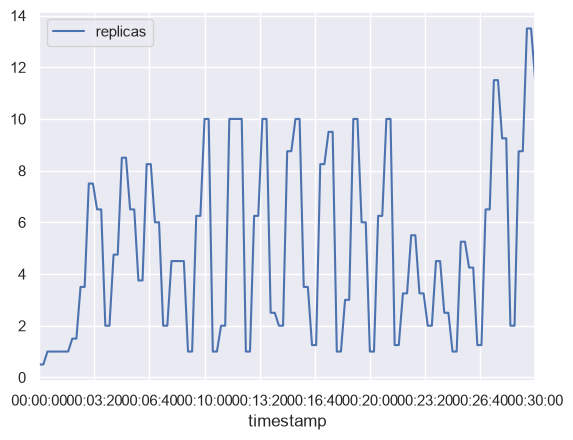

In [281]:
deployment_status_agg_df[
    deployment_status_agg_df.autoscaler=="keda"][
    deployment_status_agg_df.deployment == "globeco-fix-engine"
].plot(x="timestamp", y="replicas")

'globeco-allocation-service'

'hpa'

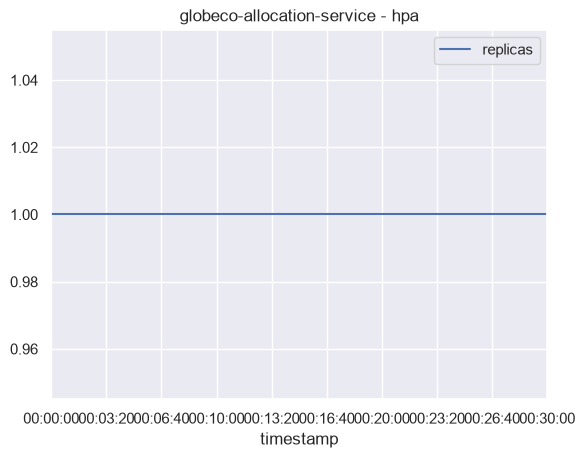

'keda'

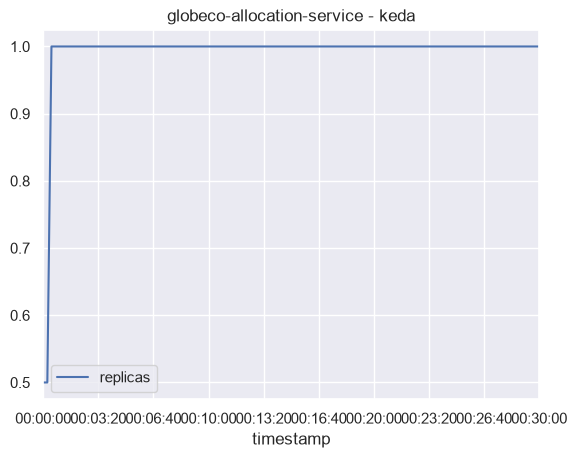

'globeco-confirmation-service'

'hpa'

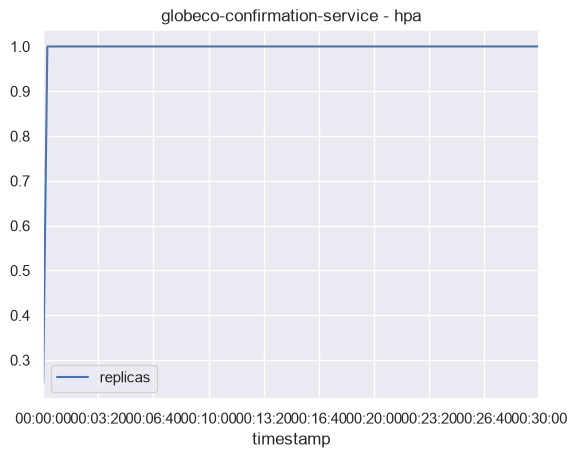

'keda'

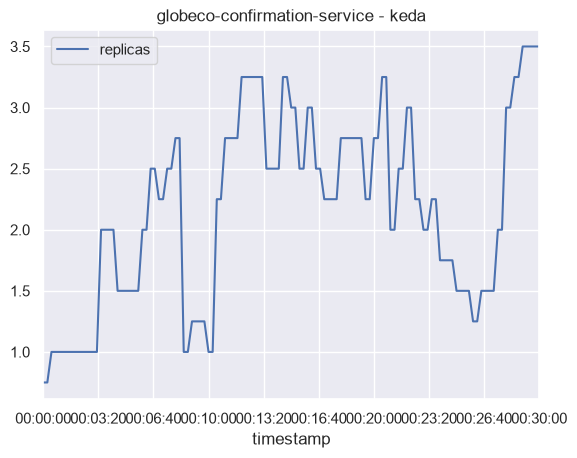

'globeco-execution-service'

'hpa'

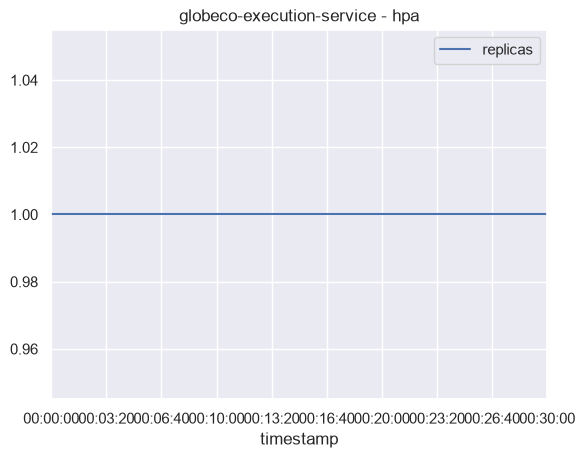

'keda'

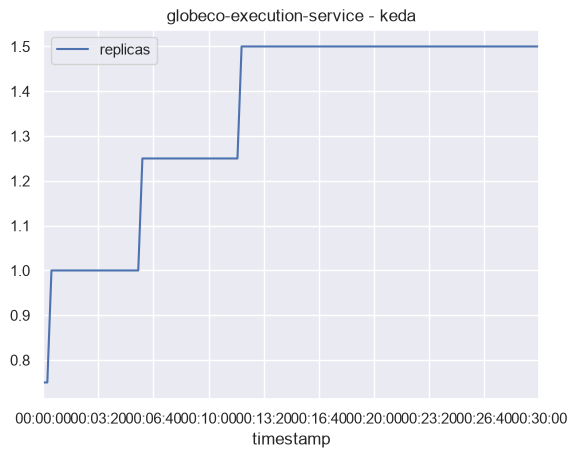

'globeco-fix-engine'

'hpa'

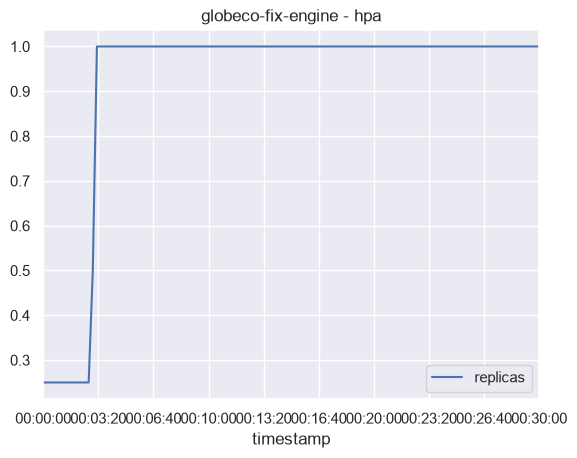

'keda'

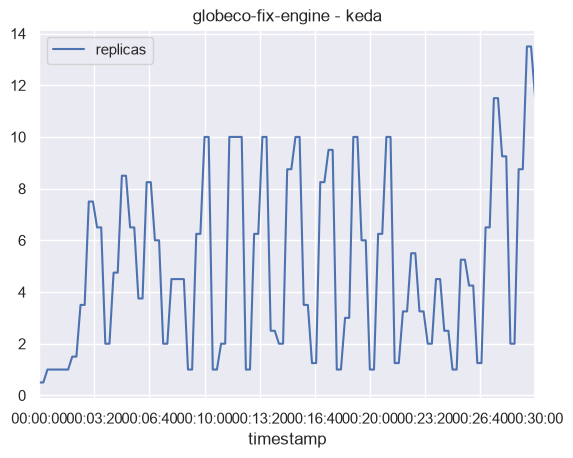

'globeco-order-generation-service'

'hpa'

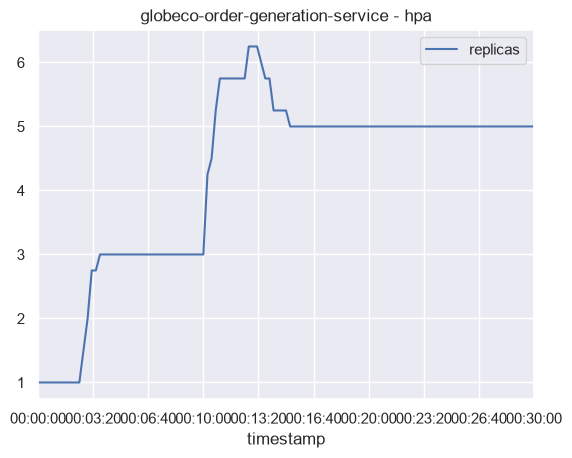

'keda'

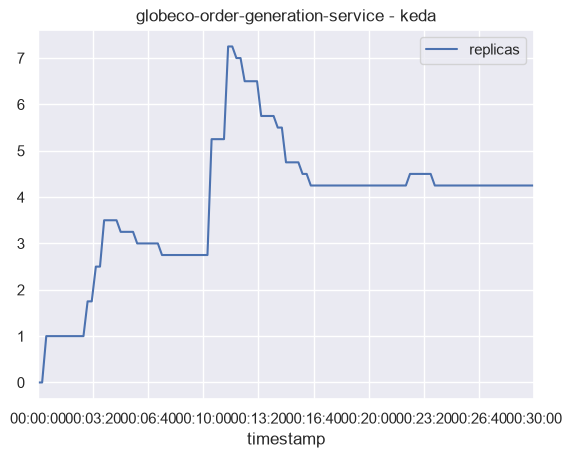

'globeco-order-service'

'hpa'

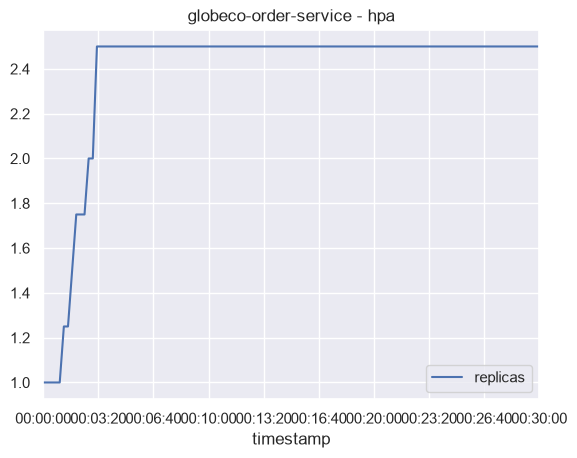

'keda'

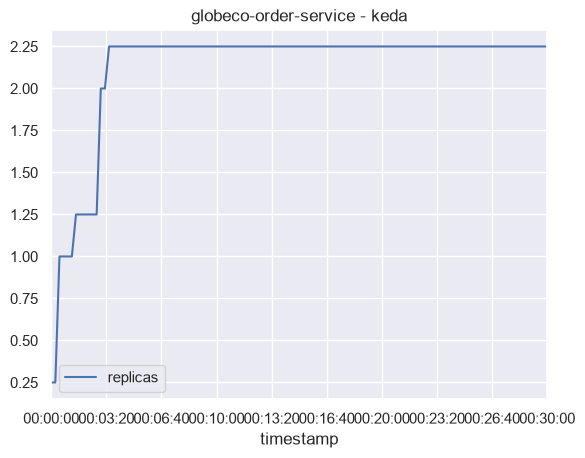

'globeco-portfolio-accounting-service'

'hpa'

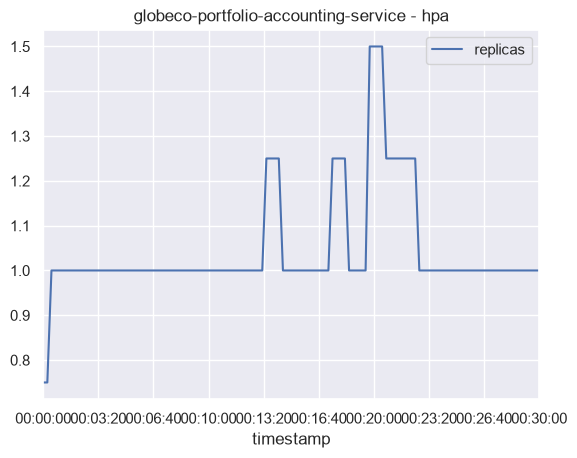

'keda'

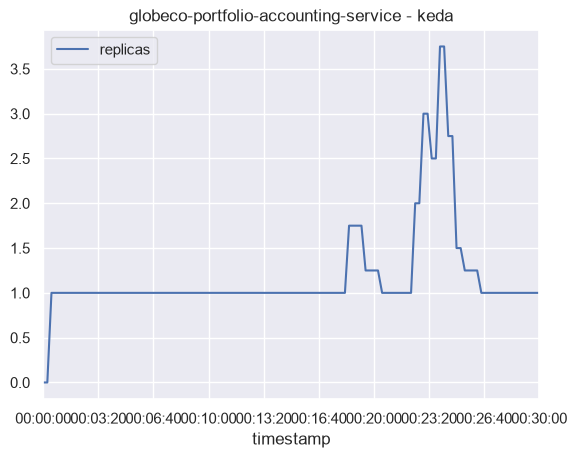

'globeco-portfolio-management-portal'

'hpa'

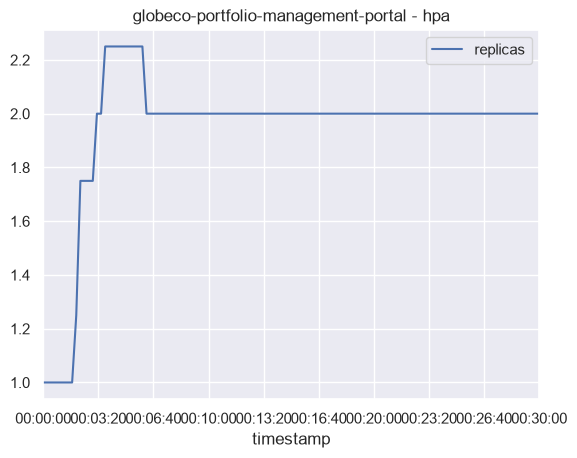

'keda'

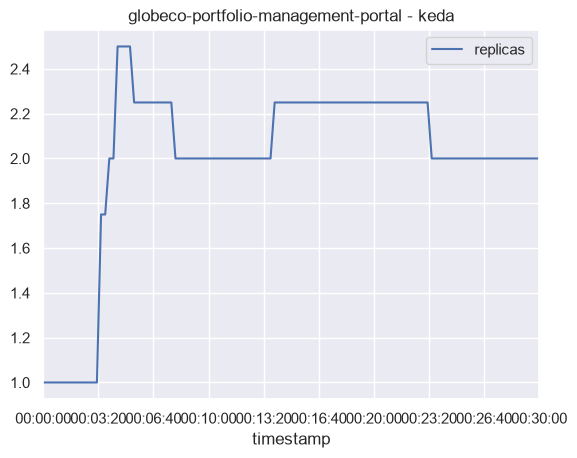

'globeco-portfolio-service'

'hpa'

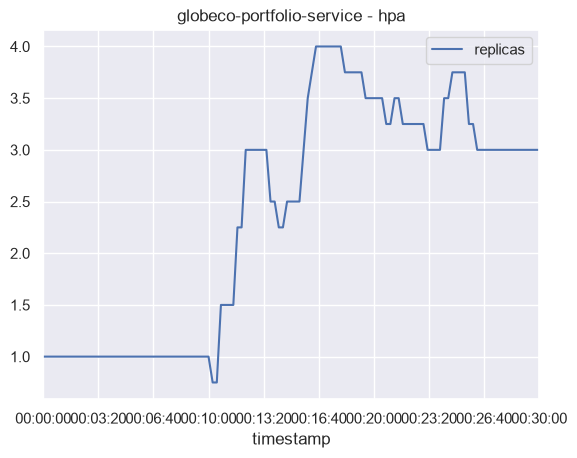

'keda'

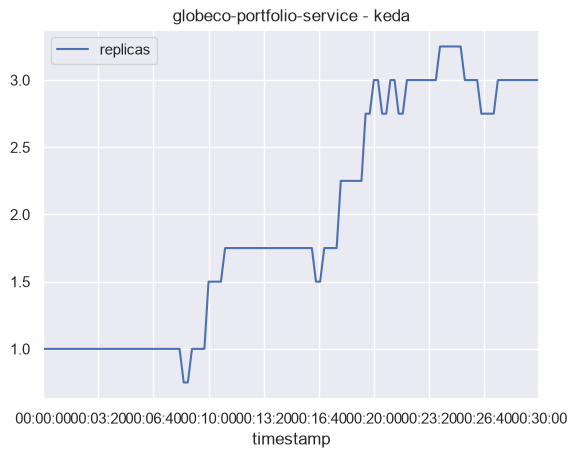

'globeco-pricing-service'

'hpa'

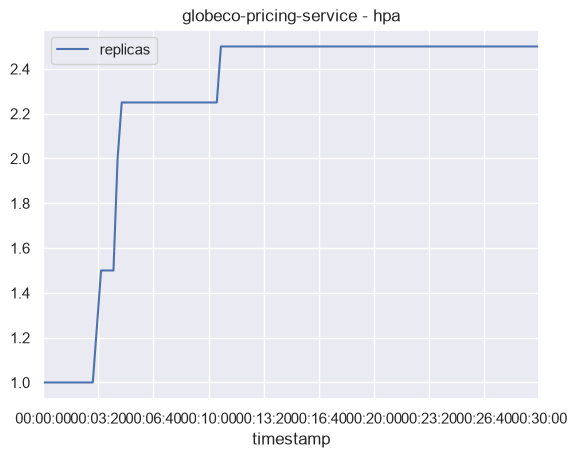

'keda'

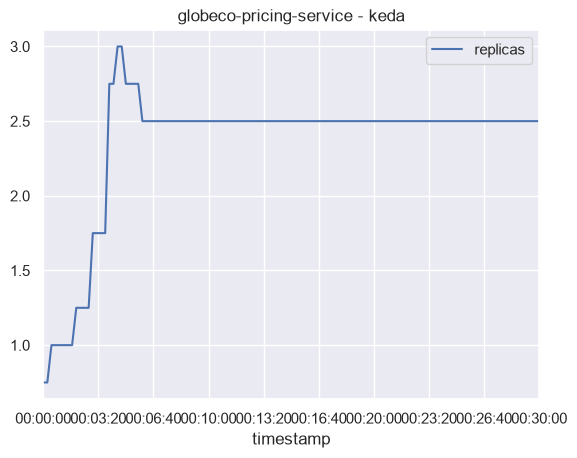

'globeco-security-service'

'hpa'

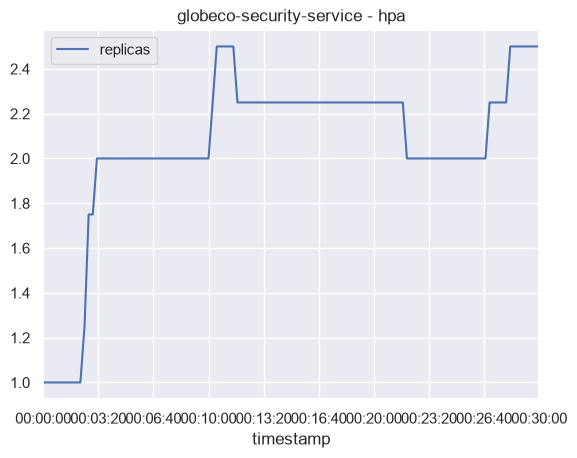

'keda'

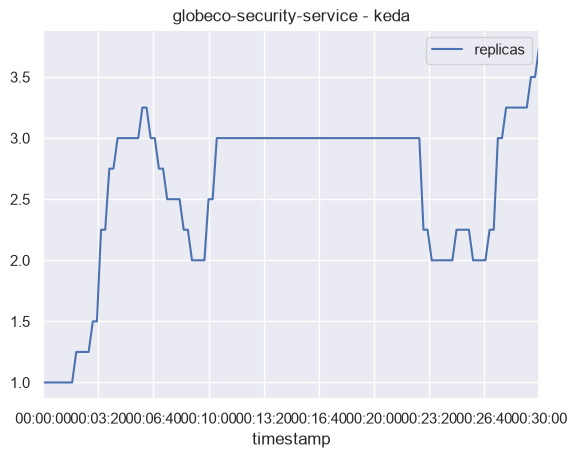

'globeco-trade-service'

'hpa'

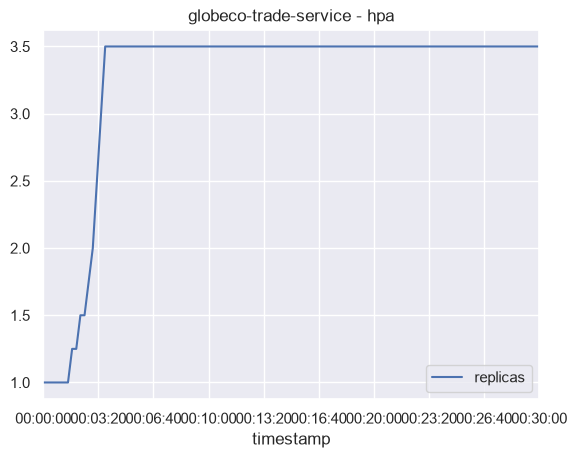

'keda'

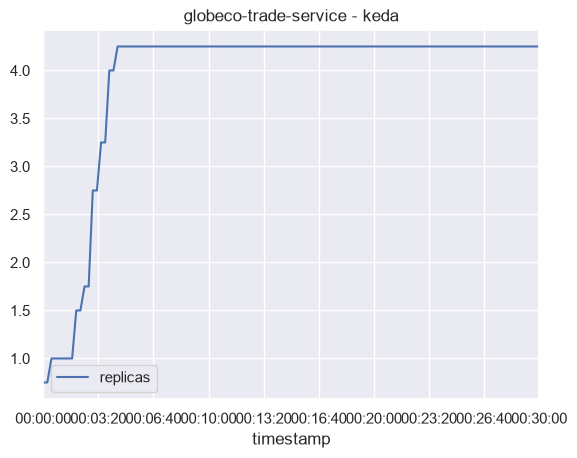

In [282]:
# Plot each combination of deployment and autoscaler
for deployment in deployment_status_agg_df.deployment.unique():
    display(deployment)
    for autoscaler in deployment_status_agg_df.autoscaler.unique():
        if autoscaler in ["vpa", "none"]:
            continue
        display(autoscaler)
        df = deployment_status_agg_df[
            (deployment_status_agg_df.deployment == deployment) &
            (deployment_status_agg_df.autoscaler == autoscaler)
        ]
        df.plot(x="timestamp", y="replicas", title=f"{deployment} - {autoscaler}")
        plt.show()


## Dissertation-ready diagram

In [283]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t


# =====================================================================
# Configuration
# =====================================================================

PROMETHEUS_INTERVAL_SECONDS = 15

# Options:
#   "t"      -> Student's t critical value
#   "normal" -> 1.96 * SE
CI_METHOD = "t"

CONFIDENCE_LEVEL = 0.95


# =====================================================================
# Load and prepare replica-count data
# =====================================================================

metric = "kube_deployment_status_replicas_available"
column_label = "replicas"

deployment_status_df = get_merged_range_metric_df(
    files,
    RUN,
    s3_bucket,
    metric,
    column_label,
)


# ---------------------------------------------------------------------
# Re-baseline each trial so each trial starts at t = 0.
# ---------------------------------------------------------------------

deployment_status_df["timestamp"] = (
    deployment_status_df["timestamp"]
    - deployment_status_df
        .groupby("trial_id")["timestamp"]
        .transform("min")
)


# ---------------------------------------------------------------------
# Place observations onto a common elapsed-time grid.
#
# This prevents small differences in Prometheus scrape timestamps from
# causing observations from different trials to be treated as different
# time points.
# ---------------------------------------------------------------------

deployment_status_df["elapsed_seconds"] = (
    deployment_status_df["timestamp"]
    / PROMETHEUS_INTERVAL_SECONDS
).round() * PROMETHEUS_INTERVAL_SECONDS

deployment_status_df["elapsed_seconds"] = (
    deployment_status_df["elapsed_seconds"].astype(int)
)


# Optional convenience column for plotting.
deployment_status_df["elapsed_hours"] = (
    deployment_status_df["elapsed_seconds"] / 3600
)


# ---------------------------------------------------------------------
# Restrict analysis to relevant GlobeCo deployments.
# ---------------------------------------------------------------------

deployment_status_df = deployment_status_df[
    deployment_status_df["deployment"].str.startswith(
        "globeco",
        na=False,
    )
].copy()

deployment_status_df = deployment_status_df[
    deployment_status_df["deployment"] != "globeco-debug-tools"
].copy()

deployment_status_df = deployment_status_df[
    deployment_status_df["autoscaler"].isin(["hpa", "keda"])
].copy()


# =====================================================================
# Ensure one observation per trial/deployment/time point
# =====================================================================
#
# This is important statistically: the independent experimental unit is
# the trial, not an individual Prometheus observation.
#
# If rounding places more than one observation from the same trial into
# the same time bin, average those observations first.
# =====================================================================

trial_replica_df = (
    deployment_status_df
    .groupby(
        [
            "autoscaler",
            "trial_id",
            "deployment",
            "elapsed_seconds",
        ],
        as_index=False,
    )
    .agg(
        replicas=("replicas", "mean")
    )
)

trial_replica_df["elapsed_hours"] = (
    trial_replica_df["elapsed_seconds"] / 3600
)


# =====================================================================
# Calculate mean and 95% CI across trials
# =====================================================================

def summarize_replicas(
    group,
    confidence_level=0.95,
    ci_method="t",
):
    """
    Calculate the mean replica count and confidence interval across
    independent trials.

    Parameters
    ----------
    group : pandas.DataFrame
        Trial-level observations for one autoscaler/deployment/time point.

    confidence_level : float
        Confidence level, e.g. 0.95.

    ci_method : {"t", "normal"}
        "t":
            Student's t confidence interval.

        "normal":
            Normal approximation. For a 95% CI this is approximately
            mean +/- 1.96 * SE.
    """

    x = group["replicas"].dropna()

    n = len(x)
    mean = x.mean()

    if n > 1:
        sd = x.std(ddof=1)
        se = sd / np.sqrt(n)

        alpha = 1 - confidence_level

        if ci_method == "t":
            critical_value = t.ppf(
                1 - alpha / 2,
                df=n - 1,
            )

        elif ci_method == "normal":
            # Exactly 1.95996... for a 95% CI.
            # This is conventionally reported as 1.96.
            from scipy.stats import norm

            critical_value = norm.ppf(
                1 - alpha / 2
            )

        else:
            raise ValueError(
                "ci_method must be 't' or 'normal'"
            )

        margin = critical_value * se

    else:
        se = np.nan
        critical_value = np.nan
        margin = np.nan

    return pd.Series({
        "mean": mean,
        "sd": x.std(ddof=1) if n > 1 else np.nan,
        "se": se,
        "critical_value": critical_value,
        "ci_lower": mean - margin,
        "ci_upper": mean + margin,
        "n": n,
    })


replica_summary_df = (
    trial_replica_df
    .groupby(
        [
            "autoscaler",
            "deployment",
            "elapsed_seconds",
        ]
    )
    .apply(
        summarize_replicas,
        confidence_level=CONFIDENCE_LEVEL,
        ci_method=CI_METHOD,
        include_groups=False,
    )
    .reset_index()
)


# Convenience plotting column.
replica_summary_df["elapsed_hours"] = (
    replica_summary_df["elapsed_seconds"] / 3600
)


# Replica counts cannot be negative.
replica_summary_df["ci_lower"] = (
    replica_summary_df["ci_lower"].clip(lower=0)
)

/var/folders/sh/1_33sr491y7488wgvd7hldqr0000gn/T/ipykernel_79772/2623725638.py:61: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round() * PROMETHEUS_INTERVAL_SECONDS


In [284]:
def plot_autoscaling_behavior(
    raw_df,
    summary_df,
    autoscaler,
    show_trials=True,
    ncols=3,
):
    deployments = sorted(
        summary_df.loc[
            summary_df["autoscaler"] == autoscaler,
            "deployment",
        ].unique()
    )

    nrows = math.ceil(len(deployments) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(15, 3.3 * nrows),
        sharex=True,
        squeeze=False,
    )

    axes = axes.flatten()

    for ax, deployment in zip(axes, deployments):

        raw = raw_df[
            (raw_df["autoscaler"] == autoscaler)
            & (raw_df["deployment"] == deployment)
        ]

        summary = summary_df[
            (summary_df["autoscaler"] == autoscaler)
            & (summary_df["deployment"] == deployment)
        ].sort_values("elapsed_seconds")


        # -------------------------------------------------------------
        # Individual trial trajectories
        # -------------------------------------------------------------
        if show_trials:
            for trial_id, trial in raw.groupby("trial_id"):

                trial = trial.sort_values("elapsed_seconds")

                ax.step(
                    trial["elapsed_hours"],
                    trial["replicas"],
                    where="post",
                    linewidth=0.6,
                    alpha=0.10,
                )


        # -------------------------------------------------------------
        # 95% confidence interval
        # -------------------------------------------------------------
        ax.fill_between(
            summary["elapsed_hours"],
            summary["ci_lower"],
            summary["ci_upper"],
            step="post",
            alpha=0.20,
            linewidth=0,
            label="95% CI",
        )


        # -------------------------------------------------------------
        # Mean replica trajectory
        # -------------------------------------------------------------
        ax.step(
            summary["elapsed_hours"],
            summary["mean"],
            where="post",
            linewidth=1.6,
            label="Mean",
        )


        title = deployment.removeprefix("globeco-")

        ax.set_title(title)
        ax.set_ylim(bottom=0)

        ax.grid(
            axis="y",
            alpha=0.25,
            linewidth=0.5,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


    # Hide unused panels.
    for ax in axes[len(deployments):]:
        ax.set_visible(False)


    fig.supxlabel("Elapsed Trial Time (hours)")
    fig.supylabel("Available Replicas")

    fig.suptitle(
        f"{autoscaler.upper()} Autoscaling Behavior",
        fontsize=15,
        y=1.01,
    )


    # Use the first visible axis for the shared legend.
    if deployments:
        handles, labels = axes[0].get_legend_handles_labels()

        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.995),
            ncol=2,
            frameon=False,
        )


    fig.tight_layout(
        rect=[0.02, 0.02, 1, 0.96]
    )

    return fig

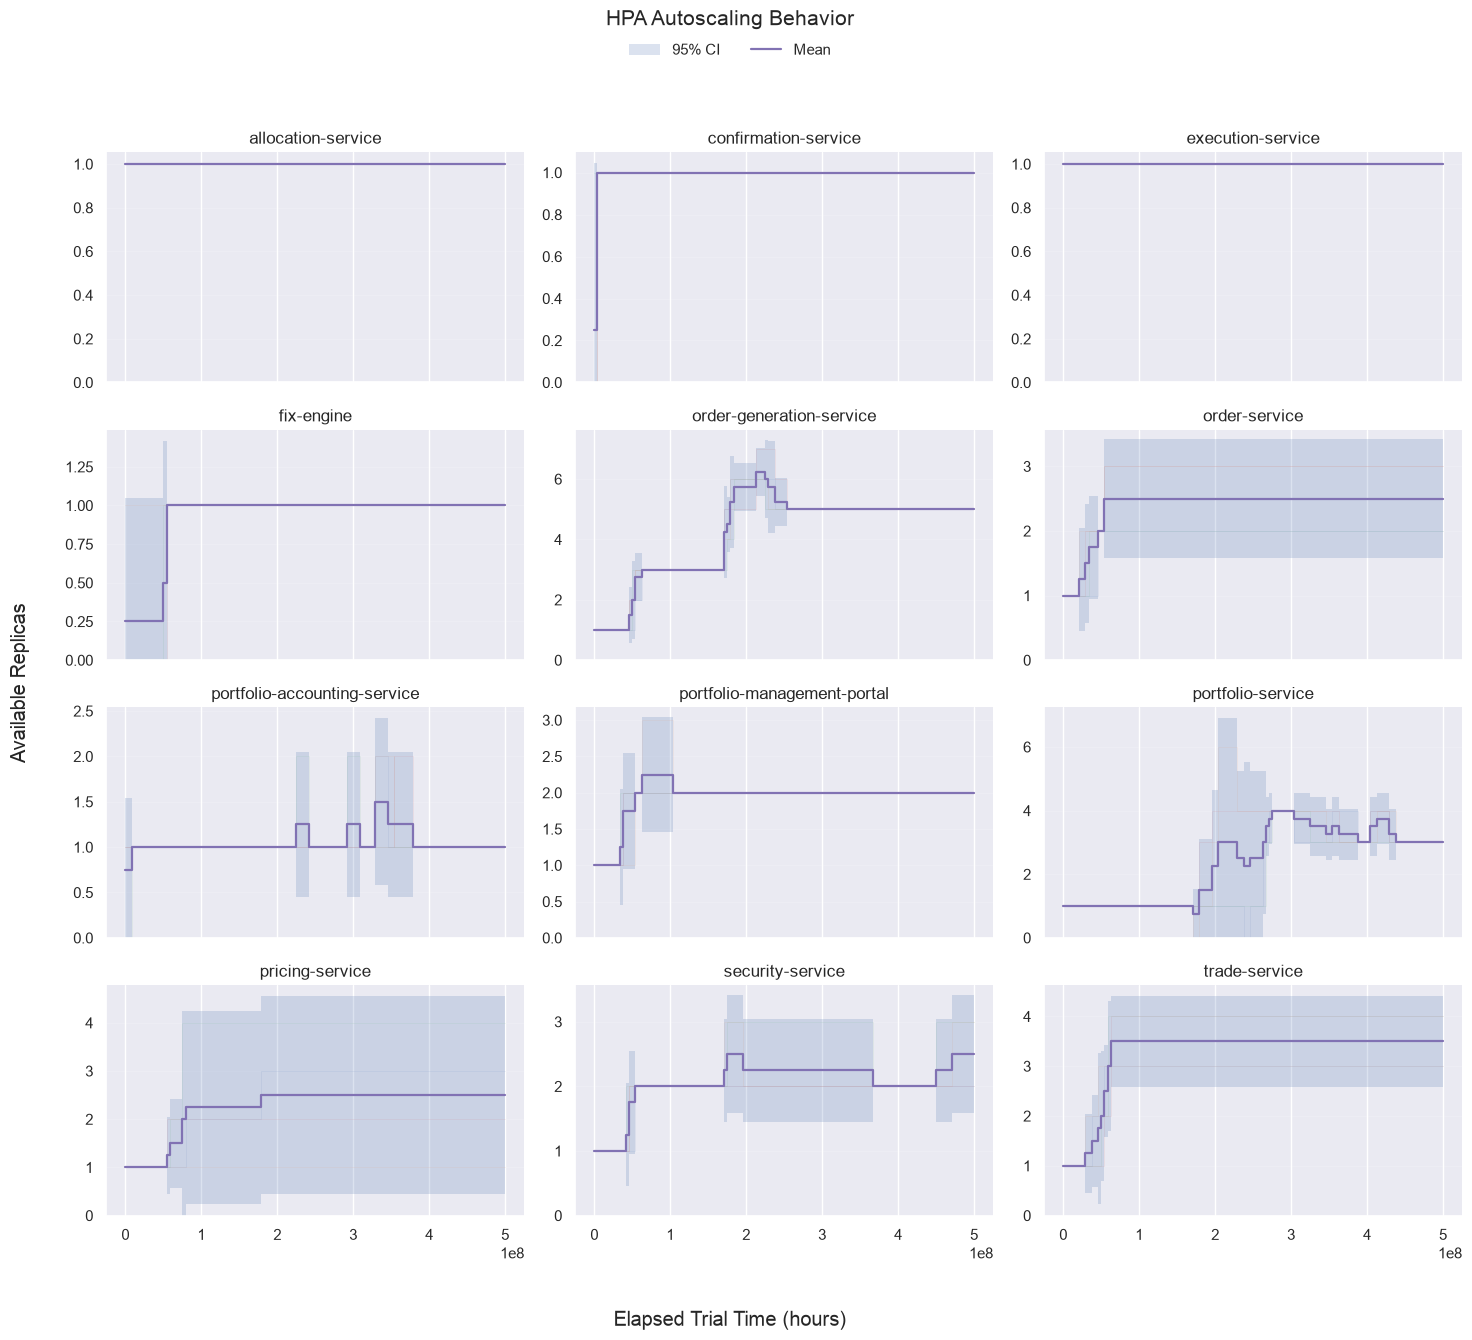

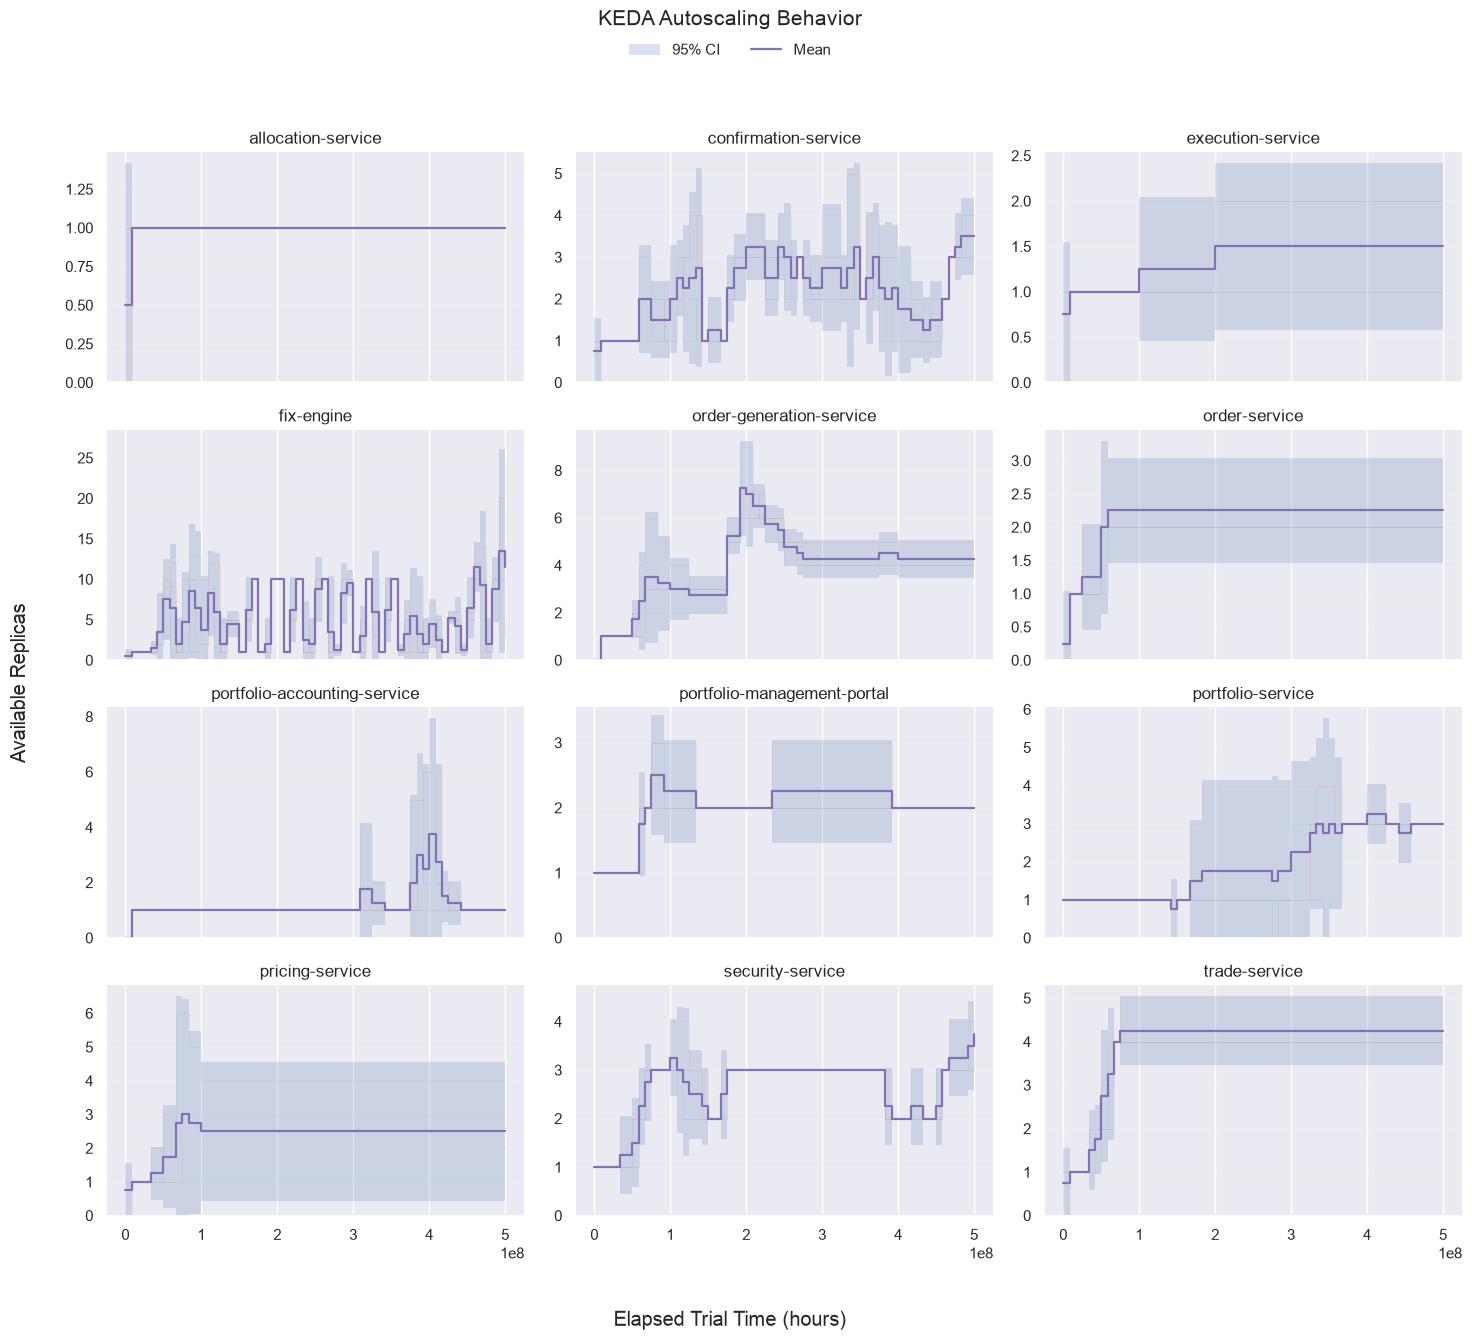

In [285]:
fig_hpa = plot_autoscaling_behavior(
    trial_replica_df,
    replica_summary_df,
    autoscaler="hpa",
)

plt.show()


fig_keda = plot_autoscaling_behavior(
    trial_replica_df,
    replica_summary_df,
    autoscaler="keda",
)

plt.show()

In [286]:
fig_hpa.savefig(
    "../figures/hpa_autoscaling_behavior.png",
    bbox_inches="tight",
)

fig_keda.savefig(
    "../figures/keda_autoscaling_behavior.png",
    bbox_inches="tight",
)

# Analyze scaling (vertical)

In [287]:
# kube_pod_container_resource_requests-container,memory

metric = "kube_pod_container_resource_requests-container,memory"
column_label = "bytes"

memory_resource_requests_df = get_merged_range_metric_df(
    files,
    RUN,
    s3_bucket,
    metric,
    column_label,
)

memory_resource_requests_df

,timestamp,container,bytes,trial_id,autoscaler
0,2026-09-18 20:48:48.766000032,envoy,536870912.0,trial0001,hpa
1,2026-09-18 20:49:03.766000032,envoy,536870912.0,trial0001,hpa
2,2026-09-18 20:49:18.766000032,envoy,536870912.0,trial0001,hpa
3,2026-09-18 20:49:33.766000032,envoy,536870912.0,trial0001,hpa
4,2026-09-18 20:49:48.766000032,envoy,536870912.0,trial0001,hpa
...,...,...,...,...,...
45147,2026-09-19 10:09:37.052000046,shutdown-manager,33554432.0,trial0016,none
45148,2026-09-19 10:09:52.052000046,shutdown-manager,33554432.0,trial0016,none
45149,2026-09-19 10:10:07.052000046,shutdown-manager,33554432.0,trial0016,none
45150,2026-09-19 10:10:22.052000046,shutdown-manager,33554432.0,trial0016,none


In [288]:
memory_resource_requests_df.columns

Index(['timestamp', 'container', 'bytes', 'trial_id', 'autoscaler'], dtype='str')

In [289]:
metric = "kube_pod_container_resource_requests-container,cpu"
column_label = "cores"

cpu_resource_requests_df = get_merged_range_metric_df(
    files,
    RUN,
    s3_bucket,
    metric,
    column_label,
)

cpu_resource_requests_df

,timestamp,container,cores,trial_id,autoscaler
0,2026-09-18 20:48:48.766000032,envoy,0.10,trial0001,hpa
1,2026-09-18 20:49:03.766000032,envoy,0.10,trial0001,hpa
2,2026-09-18 20:49:18.766000032,envoy,0.10,trial0001,hpa
3,2026-09-18 20:49:33.766000032,envoy,0.10,trial0001,hpa
4,2026-09-18 20:49:48.766000032,envoy,0.10,trial0001,hpa
...,...,...,...,...,...
45147,2026-09-19 10:09:37.052000046,shutdown-manager,0.01,trial0016,none
45148,2026-09-19 10:09:52.052000046,shutdown-manager,0.01,trial0016,none
45149,2026-09-19 10:10:07.052000046,shutdown-manager,0.01,trial0016,none
45150,2026-09-19 10:10:22.052000046,shutdown-manager,0.01,trial0016,none


In [290]:
cpu_resource_requests_df.columns

Index(['timestamp', 'container', 'cores', 'trial_id', 'autoscaler'], dtype='str')

## Dissertation-ready diagram

In [291]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t, norm


# =====================================================================
# Configuration
# =====================================================================

PROMETHEUS_INTERVAL_SECONDS = 15

# "t"      -> Student's t confidence interval
# "normal" -> normal approximation (approximately 1.96 * SE for 95% CI)
CI_METHOD = "t"

CONFIDENCE_LEVEL = 0.95

# Autoscalers included in this analysis.
# "none" provides the static-resource baseline.
AUTOSCALERS = ["vpa", "none"]

In [292]:
# =====================================================================
# Memory requests
# =====================================================================

globeco_containers = [
        'globeco-allocation-service',
        'globeco-confirmation-service',
        'globeco-execution-service',
        'globeco-fix-engine',
        'globeco-order-generation-service',
        'globeco-order-service',
        'globeco-portfolio-accounting-service',
        'globeco-portfolio-management-portal',
        'globeco-portfolio-service',
        'globeco-pricing-service',
        'globeco-security-service',
        'globeco-trade-service',
        ]

metric = "kube_pod_container_resource_requests-container,memory"
column_label = "bytes"

memory_resource_requests_df = get_merged_range_metric_df(
    files,
    RUN,
    s3_bucket,
    metric,
    column_label,
)

# Filter memory_resource_requests_df to contain only globeco containers
memory_resource_requests_df = memory_resource_requests_df[
    memory_resource_requests_df["container"].isin(globeco_containers)
]


# =====================================================================
# CPU requests
# =====================================================================

metric = "kube_pod_container_resource_requests-container,cpu"
column_label = "cores"

cpu_resource_requests_df = get_merged_range_metric_df(
    files,
    RUN,
    s3_bucket,
    metric,
    column_label,
)

# Filter cpu_resource_requests_df to contain only globeco containers
cpu_resource_requests_df = cpu_resource_requests_df[
    cpu_resource_requests_df["container"].isin(globeco_containers)
]

In [293]:
def prepare_vpa_resource_df(
    df,
    value_column,
    prometheus_interval_seconds=15,
):
    """
    Prepare CPU or memory resource-request data for VPA analysis.

    Each trial is re-baselined to elapsed time = 0 and observations are
    placed onto a common Prometheus time grid.
    """

    df = df.copy()

    # -------------------------------------------------------------
    # Restrict to VPA and no-autoscaler baseline.
    # -------------------------------------------------------------
    df = df[
        df["autoscaler"].isin(["vpa", "none"])
    ].copy()


    # -------------------------------------------------------------
    # Restrict to GlobeCo application containers.
    # -------------------------------------------------------------
    df = df[
        df["container"].str.startswith(
            "globeco",
            na=False,
        )
    ].copy()

    df = df[
        df["container"] != "globeco-debug-tools"
    ].copy()


    # -------------------------------------------------------------
    # Re-baseline each trial to t = 0.
    #
    # Important: baseline by trial rather than by autoscaler/container,
    # because elapsed time represents position within the benchmark
    # trial.
    # -------------------------------------------------------------
    df["timestamp"] = (
        df["timestamp"]
        - df.groupby("trial_id")["timestamp"].transform("min")
    )


    # -------------------------------------------------------------
    # Put observations onto common Prometheus time grid.
    # -------------------------------------------------------------
    df["elapsed_seconds"] = (
        df["timestamp"]
        / prometheus_interval_seconds
    ).round() * prometheus_interval_seconds

    df["elapsed_seconds"] = (
        df["elapsed_seconds"].astype(int)
    )

    df["elapsed_hours"] = (
        df["elapsed_seconds"] / 3600
    )


    # -------------------------------------------------------------
    # Ensure exactly one value per experimental unit:
    #
    #     trial × autoscaler × container × time
    #
    # If more than one observation maps to a time bin, average them.
    # -------------------------------------------------------------
    df = (
        df
        .groupby(
            [
                "autoscaler",
                "trial_id",
                "container",
                "elapsed_seconds",
            ],
            as_index=False,
        )
        .agg(
            value=(value_column, "mean")
        )
    )

    df["elapsed_hours"] = (
        df["elapsed_seconds"] / 3600
    )

    return df

In [294]:
# CPU requests are already in cores.
vpa_cpu_df = prepare_vpa_resource_df(
    cpu_resource_requests_df,
    value_column="cores",
    prometheus_interval_seconds=PROMETHEUS_INTERVAL_SECONDS,
)

vpa_cpu_df["cpu_cores"] = vpa_cpu_df["value"]


# Memory requests: convert bytes -> MiB.
vpa_memory_df = prepare_vpa_resource_df(
    memory_resource_requests_df,
    value_column="bytes",
    prometheus_interval_seconds=PROMETHEUS_INTERVAL_SECONDS,
)

vpa_memory_df["memory_mib"] = (
    vpa_memory_df["value"] / (1024 ** 2)
)

/var/folders/sh/1_33sr491y7488wgvd7hldqr0000gn/T/ipykernel_79772/1840238908.py:57: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round() * prometheus_interval_seconds
/var/folders/sh/1_33sr491y7488wgvd7hldqr0000gn/T/ipykernel_79772/1840238908.py:57: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round() * prometheus_interval_seconds


In [295]:
def summarize_resource(
    group,
    value_column,
    confidence_level=0.95,
    ci_method="t",
):
    """
    Calculate mean and confidence interval across independent trials.
    """

    x = group[value_column].dropna()

    n = len(x)
    mean = x.mean()

    if n > 1:
        sd = x.std(ddof=1)
        se = sd / np.sqrt(n)

        alpha = 1 - confidence_level

        if ci_method == "t":

            critical_value = t.ppf(
                1 - alpha / 2,
                df=n - 1,
            )

        elif ci_method == "normal":

            critical_value = norm.ppf(
                1 - alpha / 2
            )

        else:

            raise ValueError(
                "ci_method must be 't' or 'normal'"
            )

        margin = critical_value * se

    else:

        sd = np.nan
        se = np.nan
        critical_value = np.nan
        margin = np.nan


    return pd.Series({
        "mean": mean,
        "sd": sd,
        "se": se,
        "critical_value": critical_value,
        "ci_lower": mean - margin,
        "ci_upper": mean + margin,
        "n": n,
    })

In [296]:
def create_resource_summary(
    df,
    value_column,
):
    summary_df = (
        df
        .groupby(
            [
                "autoscaler",
                "container",
                "elapsed_seconds",
            ]
        )
        .apply(
            summarize_resource,
            value_column=value_column,
            confidence_level=CONFIDENCE_LEVEL,
            ci_method=CI_METHOD,
            include_groups=False,
        )
        .reset_index()
    )

    summary_df["elapsed_hours"] = (
        summary_df["elapsed_seconds"] / 3600
    )

    summary_df["ci_lower"] = (
        summary_df["ci_lower"].clip(lower=0)
    )

    return summary_df

In [297]:
vpa_cpu_summary_df = create_resource_summary(
    vpa_cpu_df,
    value_column="cpu_cores",
)

vpa_memory_summary_df = create_resource_summary(
    vpa_memory_df,
    value_column="memory_mib",
)

In [298]:
def plot_vpa_resource_behavior(
    raw_df,
    summary_df,
    value_column,
    ylabel,
    title,
    show_trials=True,
    show_baseline_ci=False,
    ncols=3,
):
    """
    Plot VPA resource-request trajectories.

    VPA:
        faint lines = individual trials
        solid step line = mean
        shaded band = 95% CI

    none:
        dashed step line = mean static baseline

    Optionally shows the 95% CI for the baseline.
    """

    containers = sorted(
        summary_df.loc[
            summary_df["autoscaler"] == "vpa",
            "container",
        ].unique()
    )

    nrows = math.ceil(
        len(containers) / ncols
    )

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(15, 3.3 * nrows),
        sharex=True,
        squeeze=False,
    )

    axes = axes.flatten()


    for ax, container in zip(
        axes,
        containers,
    ):

        # =========================================================
        # VPA observations
        # =========================================================

        raw_vpa = raw_df[
            (raw_df["autoscaler"] == "vpa")
            & (raw_df["container"] == container)
        ]

        summary_vpa = summary_df[
            (summary_df["autoscaler"] == "vpa")
            & (summary_df["container"] == container)
        ].sort_values("elapsed_seconds")


        # ---------------------------------------------------------
        # Individual VPA trials
        # ---------------------------------------------------------

        if show_trials:

            for trial_id, trial in raw_vpa.groupby(
                "trial_id"
            ):

                trial = trial.sort_values(
                    "elapsed_seconds"
                )

                ax.step(
                    trial["elapsed_hours"],
                    trial[value_column],
                    where="post",
                    linewidth=0.6,
                    alpha=0.10,
                )


        # ---------------------------------------------------------
        # VPA 95% CI
        # ---------------------------------------------------------

        ax.fill_between(
            summary_vpa["elapsed_hours"],
            summary_vpa["ci_lower"],
            summary_vpa["ci_upper"],
            step="post",
            alpha=0.20,
            linewidth=0,
            label="VPA 95% CI",
        )


        # ---------------------------------------------------------
        # VPA mean
        # ---------------------------------------------------------

        ax.step(
            summary_vpa["elapsed_hours"],
            summary_vpa["mean"],
            where="post",
            linewidth=1.7,
            label="VPA mean",
        )


        # =========================================================
        # Static baseline ("none")
        # =========================================================

        summary_none = summary_df[
            (summary_df["autoscaler"] == "none")
            & (summary_df["container"] == container)
        ].sort_values("elapsed_seconds")


        if not summary_none.empty:

            # Optional baseline CI.
            if show_baseline_ci:

                ax.fill_between(
                    summary_none["elapsed_hours"],
                    summary_none["ci_lower"],
                    summary_none["ci_upper"],
                    step="post",
                    alpha=0.08,
                    linewidth=0,
                    label="Baseline 95% CI",
                )


            # Baseline mean.
            ax.step(
                summary_none["elapsed_hours"],
                summary_none["mean"],
                where="post",
                linewidth=1.2,
                linestyle="--",
                label="Baseline",
            )


        # =========================================================
        # Panel formatting
        # =========================================================

        panel_title = container.removeprefix(
            "globeco-"
        )

        ax.set_title(panel_title)

        ax.set_ylim(bottom=0)

        ax.grid(
            axis="y",
            alpha=0.25,
            linewidth=0.5,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


    # Hide unused axes.
    for ax in axes[len(containers):]:
        ax.set_visible(False)


    fig.supxlabel(
        "Elapsed Trial Time (hours)"
    )

    fig.supylabel(
        ylabel
    )

    fig.suptitle(
        title,
        fontsize=15,
        y=1.01,
    )


    # -------------------------------------------------------------
    # Shared figure legend
    # -------------------------------------------------------------

    handles, labels = [], []

    for ax in axes[:len(containers)]:

        h, l = ax.get_legend_handles_labels()

        for handle, label in zip(h, l):

            if label not in labels:
                handles.append(handle)
                labels.append(label)


    if handles:

        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.995),
            ncol=len(labels),
            frameon=False,
        )


    fig.tight_layout(
        rect=[0.02, 0.02, 1, 0.96]
    )

    return fig

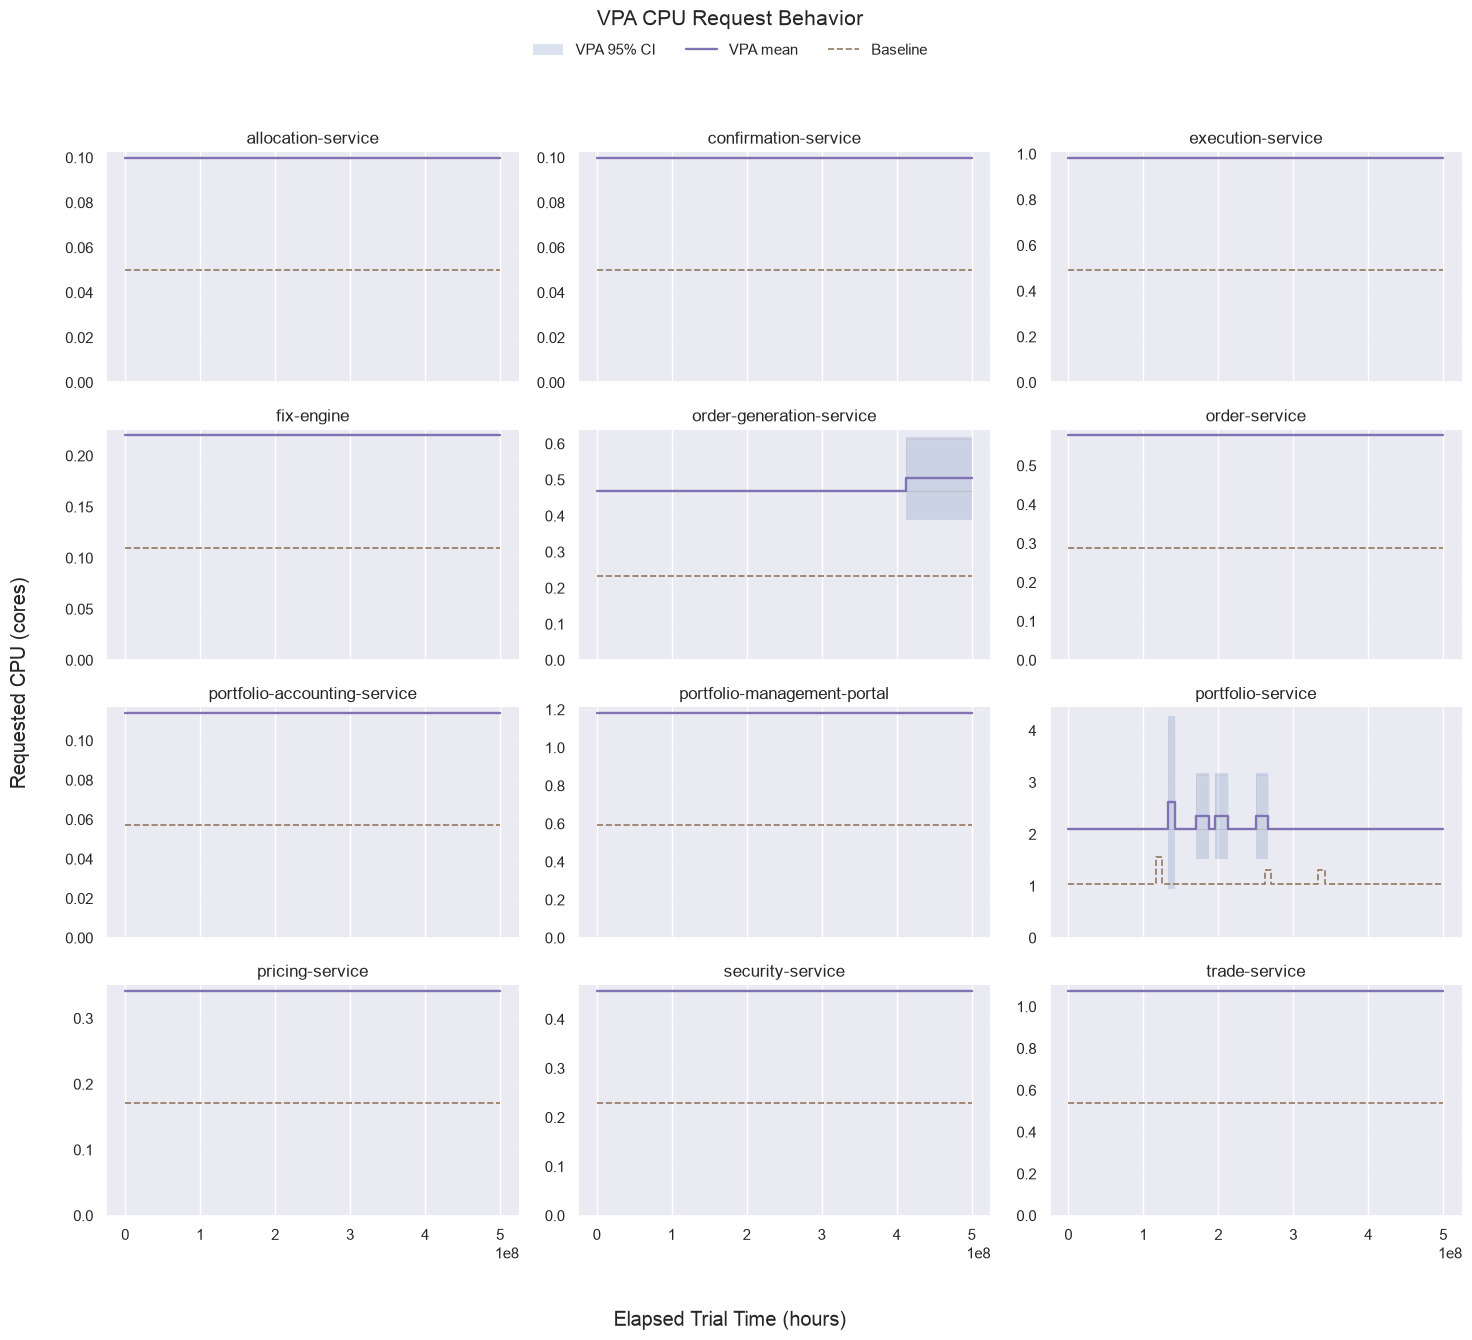

In [299]:
fig_vpa_cpu = plot_vpa_resource_behavior(
    raw_df=vpa_cpu_df,
    summary_df=vpa_cpu_summary_df,
    value_column="cpu_cores",
    ylabel="Requested CPU (cores)",
    title="VPA CPU Request Behavior",
    show_trials=True,
    show_baseline_ci=False,
)

plt.show()

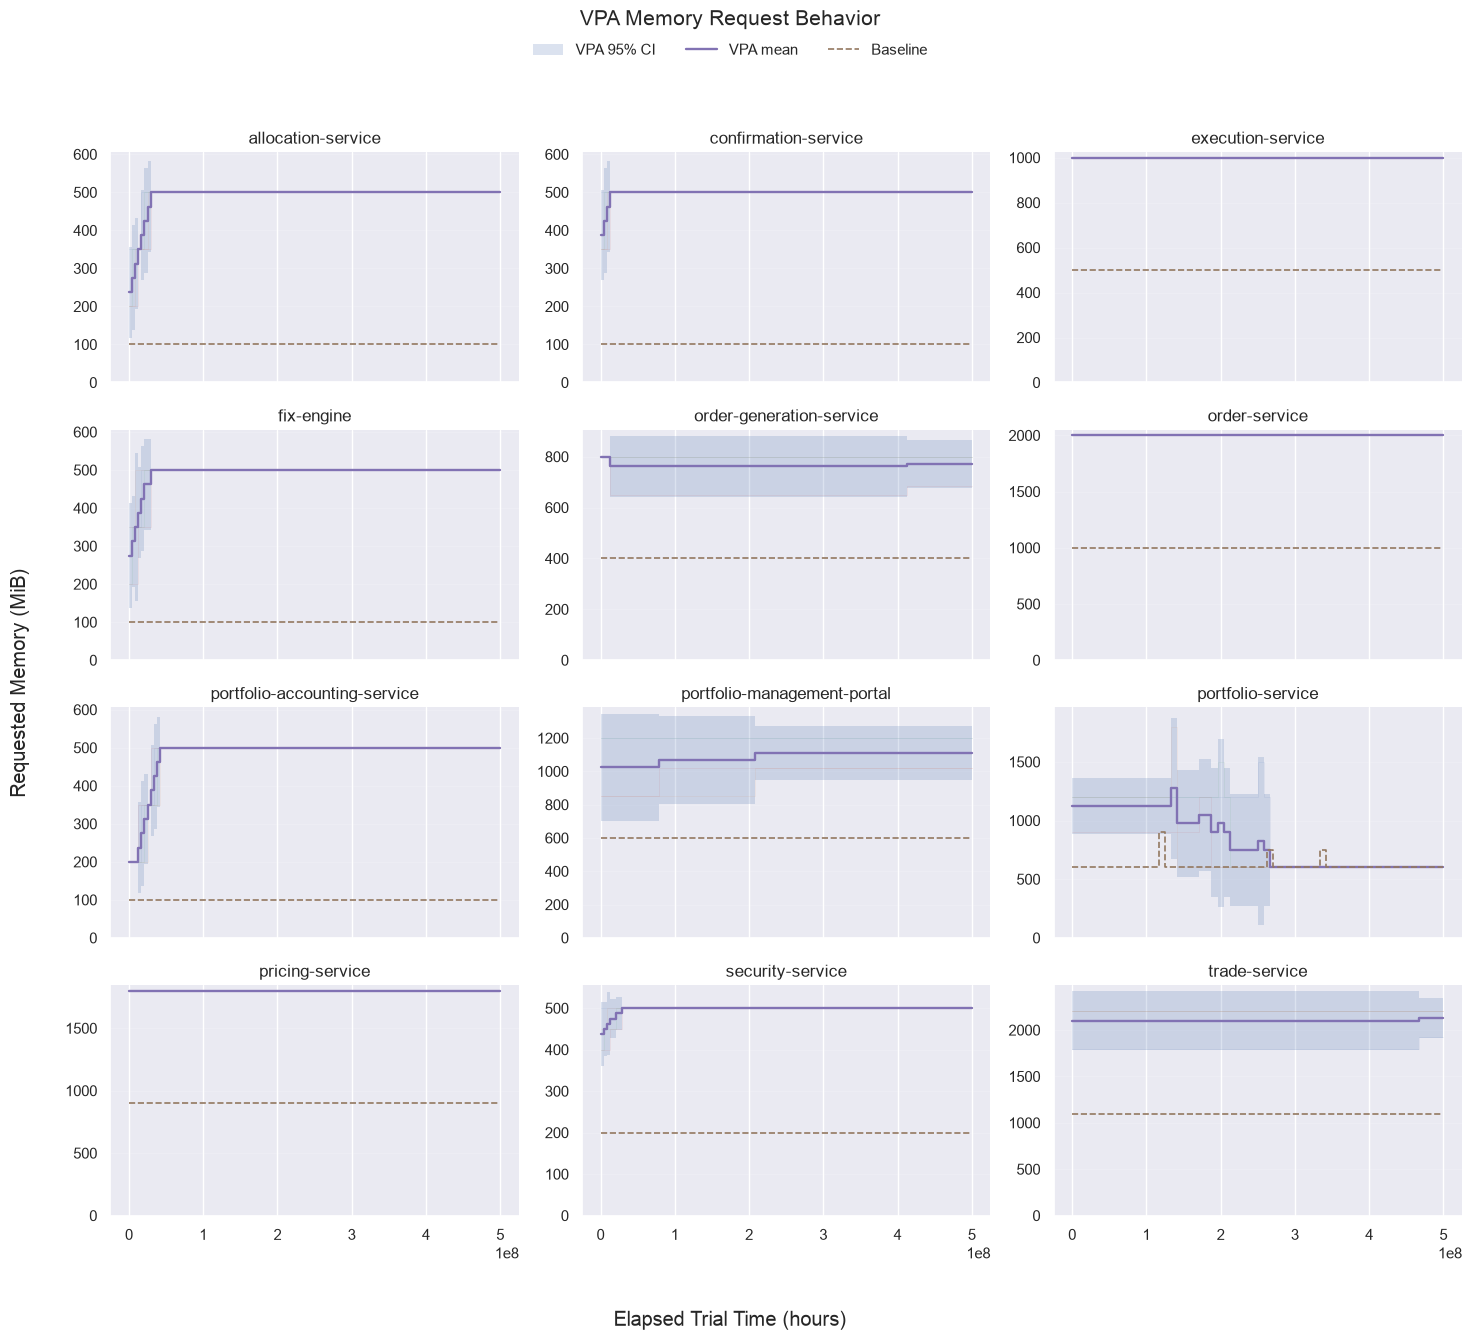

In [300]:
fig_vpa_memory = plot_vpa_resource_behavior(
    raw_df=vpa_memory_df,
    summary_df=vpa_memory_summary_df,
    value_column="memory_mib",
    ylabel="Requested Memory (MiB)",
    title="VPA Memory Request Behavior",
    show_trials=True,
    show_baseline_ci=False,
)

plt.show()

In [301]:
fig_vpa_cpu.savefig(
    "../figures/vpa_cpu_request_behavior.png",
    bbox_inches="tight",
)

fig_vpa_memory.savefig(
    "../figures/vpa_memory_request_behavior.png",
    bbox_inches="tight",
)

# Node analysis

## Get metrics from TSDB snapshots

In [302]:
client = docker.from_env()
port = 9099

queries = []

cluster_pod_requested_query = r"""
count by (node) (
  kube_pod_info
  * on (pod, namespace) group_left()
  (kube_pod_status_phase{phase=~"Running|Pending"} == 1)
)
/
sum by (node) (kube_node_status_allocatable{resource="pods"})
"""

queries.append({"name": "cluster_pod_requested", "query": cluster_pod_requested_query})


cluster_memory_requested_query = r"""
sum by (node) (
  kube_pod_container_resource_requests{resource="memory"}
  * on (pod, namespace) group_left(node)
  (
    kube_pod_info
    * on (pod, namespace) group_left()
    (kube_pod_status_phase{phase=~"Running|Pending"} == 1)
  )
)
/
sum by (node) (
  kube_node_status_allocatable{resource="memory"}
)
"""

queries.append({"name": "cluster_memory_requested", "query": cluster_memory_requested_query})



cluster_cpu_requested_query = r"""
sum by (node) (
  kube_pod_container_resource_requests{resource="cpu"}
  * on (pod, namespace) group_left(node)
  (
    kube_pod_info
    * on (pod, namespace) group_left()
    (kube_pod_status_phase{phase=~"Running|Pending"} == 1)
  )
)
/
sum by (node) (
  kube_node_status_allocatable{resource="cpu"}
)
"""

queries.append({"name": "cluster_cpu_requested", "query": cluster_cpu_requested_query})


cpu_cores_by_node_query = r"""sum by (node) (
  kube_pod_container_resource_requests{resource="cpu"}
  * on (namespace, pod) group_left(node)
  kube_pod_info
)"""

queries.append({"name": "cpu_cores_by_node", "query": cpu_cores_by_node_query})


node_cpu_usage_query = r"""
  avg(1 - rate(node_cpu_seconds_total{mode="idle"}[2m])) by (node)"""

queries.append({"name": "node_cpu_usage", "query": node_cpu_usage_query})


total_cpu_usage_ratio = r"""1 - (
  sum by (node) (
    rate(node_cpu_seconds_total{mode="idle"}[2m])
  )
  /
  sum by (node) (
    rate(node_cpu_seconds_total[2m])
  )
)
"""

queries.append({"name": "node_cpu_usage", "query": node_cpu_usage_query})


allocatable_cpu_usage_ratio_query = r"""
sum by (node) (
  label_replace(
    rate(container_cpu_usage_seconds_total{container!="", container!="POD"}[2m]),
    "node",
    "$1",
    "instance",
    "(.*)"
  )
)
/
sum by (node) (
  kube_node_status_allocatable{resource="cpu"}
)
"""

queries.append({"name": "allocatable_cpu_usage_ratio", "query": allocatable_cpu_usage_ratio_query})

cluster_cpu_usage_query = r"""
sum by (node) (
  label_replace(
    rate(
      container_cpu_usage_seconds_total{
        container!="",
        container!="POD"
      }[2m]
    ),
    "node",
    "$1",
    "instance",
    "(.*)"
  )
)
/
sum by (node) (
  kube_node_status_allocatable{resource="cpu"}
)
"""

queries.append({"name": "cluster_cpu_usage", "query": cluster_cpu_usage_query})



results = {}
for query in queries:
  df = get_metric_from_tsdb(
    s3_bucket,
    files,
    query["query"],
    client=client,
    port=port)
  results[query["name"]] = df

print(results.keys())



    

dict_keys(['cluster_pod_requested', 'cluster_memory_requested', 'cluster_cpu_requested', 'cpu_cores_by_node', 'node_cpu_usage', 'allocatable_cpu_usage_ratio', 'cluster_cpu_usage'])


## Headroom analysis

### Maximum node CPU allocation by autoscaler

In [303]:
df = results["cluster_cpu_requested"]
df.columns
df

,node,value,run_id,trial_id,autoscaler,elapsed_seconds
timestamp,,,,,,
2026-09-18 20:48:48.766000032,ip-10-0-1-150,0.312875,verification-15-percentile-large-a,trial0001,hpa,0.0
2026-09-18 20:49:03.766000032,ip-10-0-1-150,0.312875,verification-15-percentile-large-a,trial0001,hpa,15.0
2026-09-18 20:49:18.766000032,ip-10-0-1-150,0.312875,verification-15-percentile-large-a,trial0001,hpa,30.0
2026-09-18 20:49:33.766000032,ip-10-0-1-150,0.312875,verification-15-percentile-large-a,trial0001,hpa,45.0
2026-09-18 20:49:48.766000032,ip-10-0-1-150,0.312875,verification-15-percentile-large-a,trial0001,hpa,60.0
...,...,...,...,...,...,...
2026-09-19 10:09:37.052000046,ip-10-0-1-93,0.490000,verification-15-percentile-large-a,trial0016,none,1740.0
2026-09-19 10:09:52.052000046,ip-10-0-1-93,0.490000,verification-15-percentile-large-a,trial0016,none,1755.0
2026-09-19 10:10:07.052000046,ip-10-0-1-93,0.490000,verification-15-percentile-large-a,trial0016,none,1770.0


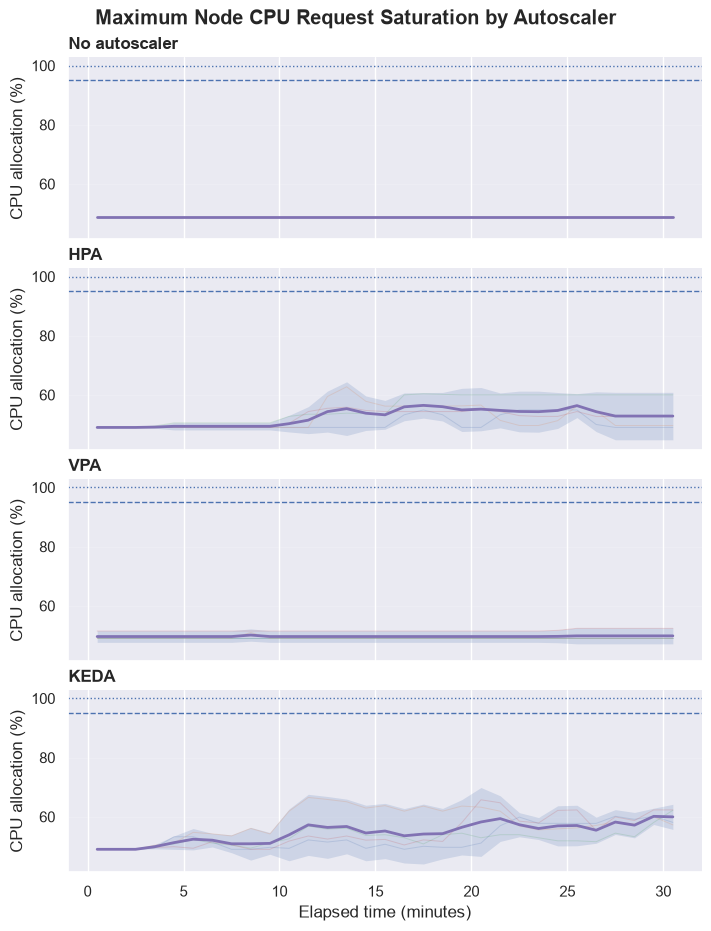

In [304]:
fig, axes, cpu_trial_binned, cpu_summary = plot_cpu_allocation(
    df,
    bin_seconds=60,
)

plt.show()

### Time at CPU Over-saturation

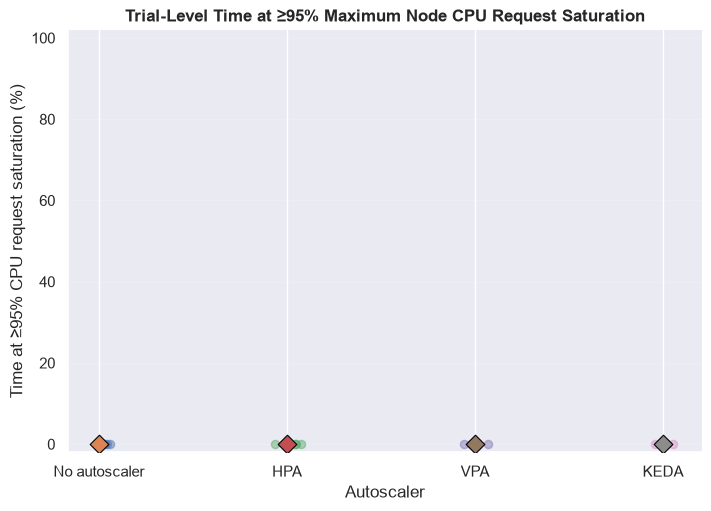

In [305]:
fig, ax, cpu_saturation_trials, cpu_saturation_summary = (
    plot_cpu_saturation_time_share(
        df,
        threshold=0.95,
    )
)

plt.show()

In [306]:
cpu_saturation_trials[
    [
        "autoscaler",
        "trial_id",
        "cpu_saturation_time_share_pct",
        "mean_max_cpu_request_ratio",
        "max_cpu_request_ratio",
    ]
].sort_values(
    ["autoscaler", "trial_id"]
)

,autoscaler,trial_id,cpu_saturation_time_share_pct,mean_max_cpu_request_ratio,max_cpu_request_ratio
0,hpa,trial0001,0.0,0.504764,0.549125
1,hpa,trial0002,0.0,0.522542,0.627375
7,hpa,trial0008,0.0,0.554042,0.603625
13,hpa,trial0014,0.0,0.523507,0.559312
3,keda,trial0004,0.0,0.529648,0.601625
8,keda,trial0009,0.0,0.580541,0.665312
12,keda,trial0013,0.0,0.527246,0.621875
14,keda,trial0015,0.0,0.545346,0.657312
4,none,trial0005,0.0,0.490000,0.490000
6,none,trial0007,0.0,0.490000,0.490000


In [307]:
cpu_saturation_summary[
    [
        "autoscaler",
        "mean",
        "ci_low",
        "ci_high",
        "count",
    ]
]

,autoscaler,mean,ci_low,ci_high,count
0,hpa,0.0,0.0,0.0,4
1,keda,0.0,0.0,0.0,4
2,none,0.0,0.0,0.0,4
3,vpa,0.0,0.0,0.0,4


### Requested CPU versus Actual CPU over time

In [308]:
cluster_cpu_requested_df = results["cluster_cpu_requested"]
cluster_cpu_usage_df = results["cluster_cpu_usage"]

In [309]:
cpu_matched, cpu_pressure, cpu_binned = (
    prepare_cpu_requested_vs_usage(
        cluster_cpu_requested_df,
        cluster_cpu_usage_df,
        bin_seconds=60,
    )
)

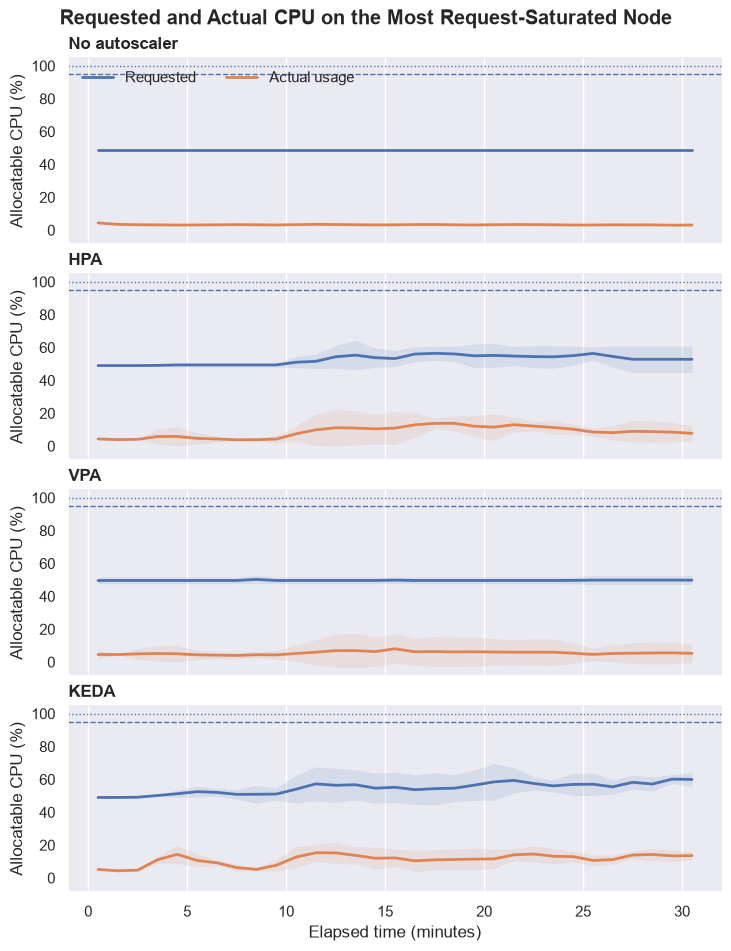

In [310]:
fig, axes, cpu_requested_usage_summary = (
    plot_cpu_requested_vs_usage(cpu_binned)
)

plt.show()

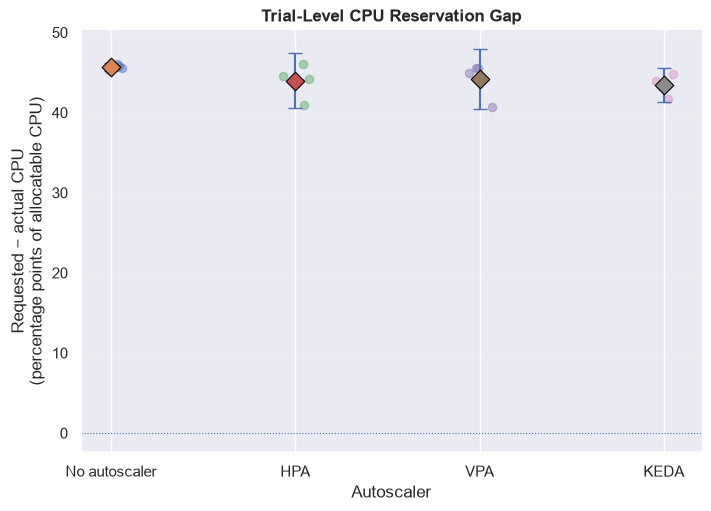

In [311]:
fig, ax, cpu_gap_trials, cpu_gap_summary = (
    plot_cpu_reservation_gap(cpu_pressure)
)

plt.show()

In [312]:
cpu_gap_trials[
    [
        "autoscaler",
        "trial_id",
        "mean_requested_ratio",
        "mean_usage_ratio",
        "reservation_gap_pct",
    ]
].sort_values(
    ["autoscaler", "trial_id"]
)

,autoscaler,trial_id,mean_requested_ratio,mean_usage_ratio,reservation_gap_pct
0,hpa,trial0001,0.504764,0.058541,44.622385
1,hpa,trial0002,0.522542,0.080465,44.207696
7,hpa,trial0008,0.554042,0.093037,46.100469
13,hpa,trial0014,0.523507,0.114042,40.946538
3,keda,trial0004,0.529648,0.112830,41.681764
8,keda,trial0009,0.580541,0.132676,44.786451
12,keda,trial0013,0.527246,0.095358,43.188767
14,keda,trial0015,0.545346,0.105316,44.002997
4,none,trial0005,0.490000,0.032459,45.754054
6,none,trial0007,0.490000,0.036431,45.356885


## Extra Plots (Rough/Exploratory)

In [316]:
df = results["cluster_pod_requested"]
df.columns

Index(['node', 'value', 'run_id', 'trial_id', 'autoscaler', 'elapsed_seconds'], dtype='str')

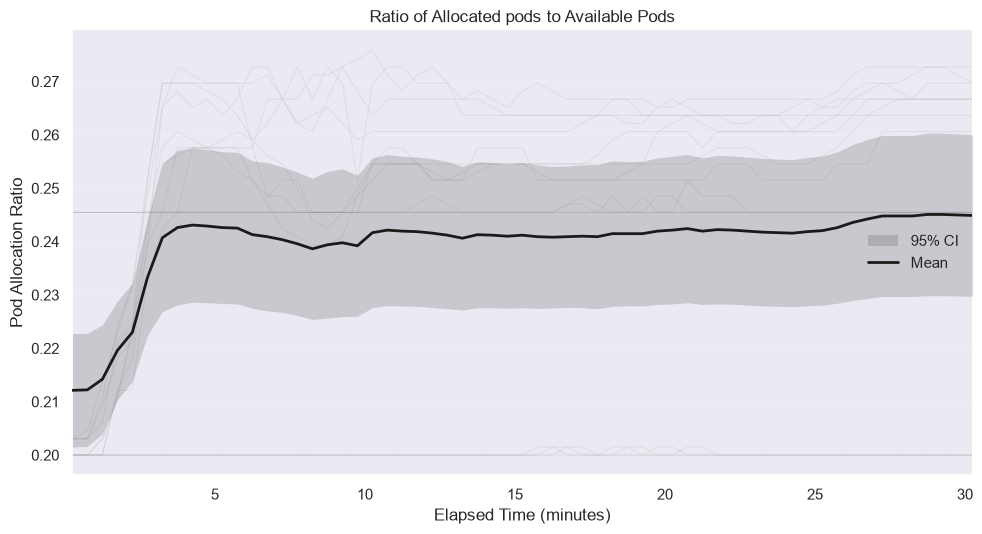

In [465]:
df = results["cluster_pod_requested"]
fig, ax, summary, trial_data = plot_trial_timeseries_binned(
    df,
    node=None,
    bin_seconds=30,
    ylabel="Pod Allocation Ratio",
    title="Ratio of Allocated pods to Available Pods",
)

plt.show()

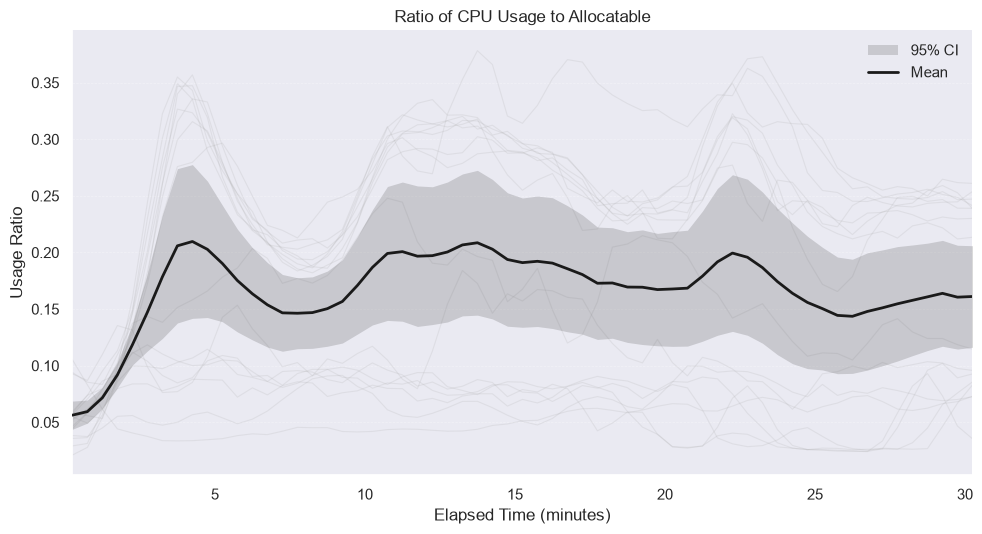

In [472]:
df = results["allocatable_cpu_usage_ratio"]
fig, ax, summary, trial_data = plot_trial_timeseries_binned(
    df,
    node=None,
    bin_seconds=30,
    ylabel="Usage Ratio",
    title="Ratio of CPU Usage to Allocatable",
)

plt.show()

In [ ]:
df = results["cluster_memory_requested"]
nodes = list(df.node.unique())
for node in nodes:
    fig, ax, summary, trial_data = plot_trial_timeseries_binned(
        df,
        node=node,
        bin_seconds=30,
        ylabel="Memory Request Ratio",
        title="Ratio of Requested Memory to Available Memory",
    )

    plt.show()

<Axes: xlabel='elapsed_seconds', ylabel='value'>

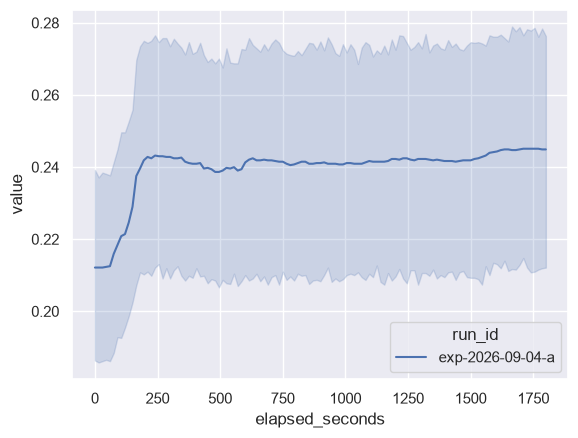

In [457]:
sns.lineplot(data=df, x="elapsed_seconds", y="value", hue="run_id")

In [ ]:
df = results["cluster_cpu_requested"]
nodes = list(df.node.unique())
for node in nodes:
    fig, ax, summary, trial_data = plot_trial_timeseries_binned(
        df,
        node=node,
        bin_seconds=30,
        ylabel="CPU Request Ratio",
        title="Ratio of Requested CPU to Available CPU",
    )

    plt.show()

In [ ]:
for name, df in results.items():
    print(name)
    sns.lineplot(data=df, x="elapsed_seconds", y="value", hue="run_id")
    plt.show()
    


# CPU Metric Analysis for Sizing

## CPU Usage

In [32]:
metric = "container_cpu_usage_seconds_total-container-_pod"
column_label = "cpu_cores"
cpu_usage_original_df = get_merged_range_metric_df(files, RUN, s3_bucket, metric, column_label)
display(cpu_usage_original_df)

,timestamp,container,pod,cpu_cores,trial_id,autoscaler
0,2026-08-20 21:18:53.302000046,envoy,envoy-globeco-globeco-gateway-6bee274d-67566d6...,0.006021,trial0001,none
1,2026-08-20 21:19:08.302000046,envoy,envoy-globeco-globeco-gateway-6bee274d-67566d6...,0.005978,trial0001,none
2,2026-08-20 21:19:23.302000046,envoy,envoy-globeco-globeco-gateway-6bee274d-67566d6...,0.005978,trial0001,none
3,2026-08-20 21:19:38.302000046,envoy,envoy-globeco-globeco-gateway-6bee274d-67566d6...,0.010752,trial0001,none
4,2026-08-20 21:19:53.302000046,envoy,envoy-globeco-globeco-gateway-6bee274d-67566d6...,0.010752,trial0001,none
...,...,...,...,...,...,...
43171,2026-08-21 01:35:05.882999897,NaN,otel-collector-daemonset-collector-966jw,0.031987,trial0004,none
43172,2026-08-21 01:35:20.882999897,NaN,otel-collector-daemonset-collector-966jw,0.031492,trial0004,none
43173,2026-08-21 01:35:35.882999897,NaN,otel-collector-daemonset-collector-966jw,0.031492,trial0004,none
43174,2026-08-21 01:35:50.882999897,NaN,otel-collector-daemonset-collector-966jw,0.029917,trial0004,none


In [67]:
df = cpu_usage_original_df.copy()
summary = df.groupby('container').agg({
    'cpu_cores': ['mean', 'std', 'min', 'max'],
})
summary

cpu_cores                      \
                                                     mean       std       min   
container                                                                       
envoy                                            0.020392  0.009021  0.003617   
envoy-gateway                                    0.002046  0.000624  0.000434   
globeco-allocation-service                       0.001294  0.000432  0.000142   
globeco-allocation-service-postgresql            0.007429  0.002044  0.001795   
globeco-confirmation-service                     0.016382  0.004121  0.003597   
globeco-debug-tools                              0.000000  0.000000  0.000000   
globeco-execution-service                        0.040693  0.015723  0.002419   
globeco-execution-service-postgresql             0.018412  0.008180  0.003589   
globeco-fix-engine                               0.017103  0.011343  0.004527   
globeco-fix-engine-postgresql                    0.013034  0.010004  0.003658   
globeco-order-generation-service                 0.126280  0.058916  0.005847   
globeco-order-generation-service-mongodb         0.008825  0.001764  0.003365   
globeco-order-generation-service-redis           0.007398  0.001370  0.002969   
globeco-order-service                            0.030830  0.028739  0.001990   
globeco-order-service-postgresql                 0.013753  0.004605  0.002363   
globeco-portfolio-accounting-service             0.005340  0.007468  0.000422   
globeco-portfolio-accounting-service-postgresql  0.013147  0.011006  0.003312   
globeco-portfolio-accounting-service-redis       0.006893  0.001220  0.002714   
globeco-portfolio-management-portal              0.124330  0.031774  0.001637   
globeco-portfolio-service                        0.044414  0.024323  0.005879   
globeco-portfolio-service-mongodb                0.007907  0.001590  0.002995   
globeco-pricing-service                          0.017515  0.014212  0.003329   
globeco-pricing-service-postgresql               0.007204  0.002432  0.002052   
globeco-security-service                         0.046944  0.020077  0.001566   
globeco-security-service-mongodb                 0.012717  0.002308  0.002997   
globeco-trade-service                            0.067052  0.050129  0.001729   
globeco-trade-service-postgresql                 0.038256  0.015420  0.005565   
kafka                                            0.090486  0.044533  0.025354   
otc-container                                    0.040954  0.015173  0.009215   
otel-collector                                   0.003227  0.001098  0.000265   
shutdown-manager                                 0.000279  0.000228  0.000040   

                                                           
                                                      max  
container                                                  
envoy                                            0.058061  
envoy-gateway                                    0.004295  
globeco-allocation-service                       0.002590  
globeco-allocation-service-postgresql            0.013186  
globeco-confirmation-service                     0.028488  
globeco-debug-tools                              0.000000  
globeco-execution-service                        0.182234  
globeco-execution-service-postgresql             0.053293  
globeco-fix-engine                               0.103699  
globeco-fix-engine-postgresql                    0.075477  
globeco-order-generation-service                 0.412061  
globeco-order-generation-service-mongodb         0.014040  
globeco-order-generation-service-redis           0.011896  
globeco-order-service                            0.292282  
globeco-order-service-postgresql                 0.029296  
globeco-portfolio-accounting-service             0.088885  
globeco-portfolio-accounting-service-postgresql  0.128791  
globeco-portfolio-accounting-service-redis       0.011188  
globeco-portfolio-management-port

In [68]:
summary.columns = summary.columns.droplevel(0)
summary.columns.name = None
display(summary)
summary = summary.T

cpu_usage_json = summary.to_json()
with open('../../globeco-helm/data/cpu_usage.json', 'w') as f:
    f.write(cpu_usage_json)

,mean,std,min,max
container,,,,
envoy,0.020392,0.009021,0.003617,0.058061
envoy-gateway,0.002046,0.000624,0.000434,0.004295
globeco-allocation-service,0.001294,0.000432,0.000142,0.002590
globeco-allocation-service-postgresql,0.007429,0.002044,0.001795,0.013186
globeco-confirmation-service,0.016382,0.004121,0.003597,0.028488
globeco-debug-tools,0.000000,0.000000,0.000000,0.000000
globeco-execution-service,0.040693,0.015723,0.002419,0.182234
globeco-execution-service-postgresql,0.018412,0.008180,0.003589,0.053293
globeco-fix-engine,0.017103,0.011343,0.004527,0.103699


In [69]:
cpu_usage_json

'{"envoy":{"mean":0.0203916481,"std":0.0090214858,"min":0.0036170479,"max":0.0580605855},"envoy-gateway":{"mean":0.0020464519,"std":0.0006235704,"min":0.0004342466,"max":0.0042945456},"globeco-allocation-service":{"mean":0.0012942203,"std":0.0004322101,"min":0.0001423085,"max":0.0025896728},"globeco-allocation-service-postgresql":{"mean":0.0074292919,"std":0.0020444158,"min":0.0017945872,"max":0.0131857358},"globeco-confirmation-service":{"mean":0.0163818913,"std":0.0041205348,"min":0.0035974349,"max":0.0284875083},"globeco-debug-tools":{"mean":0.0,"std":0.0,"min":0.0,"max":0.0},"globeco-execution-service":{"mean":0.0406932822,"std":0.0157229811,"min":0.0024191568,"max":0.1822335358},"globeco-execution-service-postgresql":{"mean":0.0184119633,"std":0.0081797257,"min":0.0035890525,"max":0.0532934142},"globeco-fix-engine":{"mean":0.0171030998,"std":0.0113427552,"min":0.0045274284,"max":0.1036992201},"globeco-fix-engine-postgresql":{"mean":0.0130340604,"std":0.0100035186,"min":0.003657821

In [34]:
cpu_usage_original_df.container.unique()
cpu_usage_original_df.columns

Index(['timestamp', 'container', 'pod', 'cpu_cores', 'trial_id', 'autoscaler'], dtype='str')

# Ignore below this line

### Calculate utilization $U_t$

In [ ]:
async_utilization, time_slice_seconds = calculate_async_utilization_by_autoscaler(files, RUN, s3_bucket, earliest_start_time, latest_end_time)



In [ ]:
L_MAX = 5  # Maximum tolerable lag
L_TARGET = 5 # Target tolerable lag
N_MIN = 0  # Minimum replicas
U_TARGET = 0.5  # Target utilization
GAMMA = 0.50
OMEGA = 0.50

metric = "kafka_consumer_group_lag_sum_ratio"
column_label = "lag"

lag_df_original = get_merged_range_metric_df(files, RUN, s3_bucket, metric, column_label)


In [382]:
n_df_original = get_merged_range_metric_df(files, RUN, s3_bucket, "kube_deployment_status_replicas-deployment", "replicas")


In [358]:
print(f"minimum timestamp = {earliest_start_time}")
print(f"maximum timestamp = {latest_end_time}")

lag_df = lag_df_original.copy()
n_df = n_df_original.copy()


# Filter columns
lag_df = lag_df[['timestamp', 'topic', 'autoscaler','trial_id', 'lag']]
print(f"Original length of lag_df: {len(lag_df)}")
# Add column "deployment" to lag_df
lag_df["deployment"] = np.where(lag_df.topic == "orders", "globeco-fix-engine", "globeco-confirmation-service")
n_df = n_df[['timestamp', 'autoscaler','trial_id', 'replicas', 'deployment']]
# Merge lag and n dataframes
lag_df = lag_df.merge(n_df, on=["timestamp", "autoscaler", "trial_id", "deployment"], suffixes=["_lag", "_n"])
# Print length of lag_df after the merge with n_df
print(f"Length of lag_df after merging with n_df: {len(lag_df)}")
# Convert timestamp to UTC 
lag_df["timestamp"] = pd.to_datetime(lag_df["timestamp"], unit="s", utc=True).astype('datetime64[us, UTC]')
# Mege lag_df and utilization on timestamp autoscaler, trial_id, and topic
lag_df = lag_df.merge(async_utilization, on=["timestamp", "autoscaler", "trial_id", "topic"], suffixes=["_lag", "_utilization"])
# Print the length of lag_df after merging with utilization: {len(lag_df)}")
print(f"Length of lag_df after merging with utilization: {len(lag_df)}")

# Calculate interval_range from the ealiest to latest start time
time_slice_index = pd.interval_range(
    start=earliest_start_time, 
    end=latest_end_time,
    freq=pd.Timedelta(seconds=time_slice_seconds),
    name="time_slice",
)


# Assign each row to a time slice based on start_time
lag_df["time_slice"] = pd.cut(
    lag_df.timestamp,
    bins=time_slice_index,
    include_lowest=True, 
    labels=time_slice_index[:],
)

# Add "theta_a_u" column
lag_df["theta_a_u"] = (lag_df.lag - L_MAX).clip(lower=0)/L_MAX

# Add "tau_a_u" time-slice column
lag_df["tau_a_u"] = np.where(lag_df.lag > L_MAX, 1, 0)

# Add overprovisioned time-slice column
lag_df["overprovisioned_ts"] = np.where(lag_df.lag == 0, 1, 0)

# Add "lag_at_or_below_target" column (ones)
lag_df["lag_at_or_below_target"] = np.where(lag_df.lag <= L_TARGET, 1, 0)

# Add "replicas_above_minimum" column (ones)
lag_df["replicas_above_minimum"] = np.where(lag_df.replicas > N_MIN, 1, 0)

# Add "overprovisioned_ratio" column
lag_df["overprovisioned_ratio"] = np.maximum(U_TARGET - lag_df.u_t, 0)/U_TARGET

# Add "theta_a_o" column
lag_df["theta_a_o"] = lag_df["overprovisioned_ratio"] * lag_df["lag_at_or_below_target"] * lag_df["replicas_above_minimum"]

# Add "underutilization" column (ones)
lag_df["underutilization"] = np.where(lag_df.u_t < U_TARGET, 1, 0)

# Add "lag_under_target" column (ones
lag_df["lag_under_target"] = np.where(lag_df.lag <= L_TARGET, 1, 0)

# Add "tau_a_o" column
lag_df["tau_a_o"] = lag_df["overprovisioned_ts"] * lag_df["lag_at_or_below_target"] * lag_df["replicas_above_minimum"]




lag_df




minimum timestamp = 2026-08-02 16:10:35.395385+00:00
maximum timestamp = 2026-08-03 00:50:06.124000+00:00
Original length of lag_df: 2614
Length of lag_df after merging with n_df: 2614
Length of lag_df after merging with utilization: 2541


,timestamp,topic,autoscaler,trial_id,lag,deployment,replicas,service_name,time_slice,idle,...,theta_a_u,tau_a_u,overprovisioned_ts,lag_at_or_below_target,replicas_above_minimum,overprovisioned_ratio,theta_a_o,underutilization,lag_under_target,tau_a_o
0,2026-08-02 16:12:50.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:12:35.395385+00:00, 2026-08-02 ...",0.674340,...,0.0,0,0,1,1,0.987190,0.987190,1,1,0
1,2026-08-02 16:13:05.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:12:50.395385+00:00, 2026-08-02 ...",0.829206,...,0.0,0,0,1,1,0.989083,0.989083,1,1,0
2,2026-08-02 16:13:20.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:13:05.395385+00:00, 2026-08-02 ...",0.921064,...,0.0,0,0,1,1,0.978951,0.978951,1,1,0
3,2026-08-02 16:13:35.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:13:20.395385+00:00, 2026-08-02 ...",0.985895,...,0.0,0,0,1,1,0.979067,0.979067,1,1,0
4,2026-08-02 16:13:50.394999+00:00,orders,vpa,trial0001,0.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:13:35.395385+00:00, 2026-08-02 ...",0.987332,...,0.0,0,1,1,1,0.971173,0.971173,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2536,2026-08-03 00:48:56.858000+00:00,fills,hpa,trial0012,2.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:48:50.395385+00:00, 2026-08-03 ...",1.007679,...,0.0,0,0,1,1,0.907623,0.907623,1,1,0
2537,2026-08-03 00:49:11.858000+00:00,fills,hpa,trial0012,1.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:49:05.395385+00:00, 2026-08-03 ...",1.008357,...,0.0,0,0,1,1,0.858011,0.858011,1,1,0
2538,2026-08-03 00:49:26.858000+00:00,fills,hpa,trial0012,1.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:49:20.395385+00:00, 2026-08-03 ...",1.008357,...,0.0,0,0,1,1,0.858011,0.858011,1,1,0
2539,2026-08-03 00:49:41.858000+00:00,fills,hpa,trial0012,1.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:49:35.395385+00:00, 2026-08-03 ...",0.974495,...,0.0,0,0,1,1,0.892283,0.892283,1,1,0


In [359]:
# Verify that there is a one-to-one relationship between timestamps and time slices

print(len(lag_df.timestamp.unique()))
print(len(lag_df.time_slice.unique()))

assert len(lag_df.timestamp.unique()) == len(lag_df.time_slice.unique())


637
637


In [ ]:
GAMMA = 0.50
OMEGA = 0.50
agg_df = (
        lag_df
        .groupby(["autoscaler"], observed=True, dropna=False)
        .agg(
            lag_mean=("lag","mean"),
            theta_a_u= ("theta_a_u", lambda values: 100.0 * values.mean()),
            theta_a_o= ("theta_a_o", lambda values: 100.0 * values.mean()),
            tau_a_u = ("tau_a_u", lambda values: 100.0 * values.mean()),
            tau_a_o = ("tau_a_o", lambda values: 100.0 * values.mean()),
        )
        .reset_index()
    )

agg_df

agg_df["theta_a"] =  GAMMA * agg_df.theta_a_u + (1 - GAMMA) * agg_df.theta_a_o
agg_df["tau_a"] =  OMEGA * agg_df.tau_a_u + (1 - OMEGA) * agg_df.tau_a_o
agg_df


,autoscaler,lag_mean,theta_a_u,theta_a_o,tau_a_u,tau_a_o,theta_a,tau_a
0,hpa,1.112150,0.093458,87.534949,0.467290,44.626168,83.162875,42.418224
1,keda,2.476562,9.875000,78.197584,14.687500,27.812500,74.781455,27.156250
2,none,0.936980,0.047562,84.350464,0.237812,42.687277,80.135319,40.564804
3,vpa,0.935127,0.253165,85.147474,1.265823,45.411392,80.902759,43.204114


<Axes: >

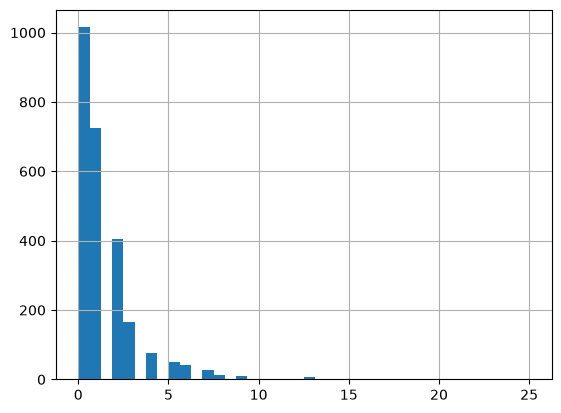

In [323]:
lag_df.lag.hist(bins=40)

In [209]:
lag_df.lag.describe()

count    2614.000000
mean        1.332823
std         1.977915
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        25.000000
Name: lag, dtype: float64

In [102]:
# get contents of {s3_bucket}/trial0001/metrics/kafka_consumer_idle_seconds_total-service_name-topic from s3
s3 = boto3.client('s3')
run_id = RUN
trial_id = "trial0001"
key = f"{run_id}/{trial_id}/metrics/kafka_consumer_idle_seconds_total-service_name-topic"
obj = s3.get_object(Bucket=s3_bucket, Key=key)
metrics = json.loads(obj['Body'].read())
metrics = metrics["data"]["result"]
metrics

[{'metric': {'service_name': 'globeco-confirmation-service', 'topic': 'fills'},
  'values': [[1785687170.395, '0.9057194978749533'],
   [1785687185.395, '0.9769030177666667'],
   [1785687200.395, '1.0110339440333334'],
   [1785687215.395, '1.0110339440333334'],
   [1785687230.395, '1.0108820449'],
   [1785687245.395, '1.0108820449'],
   [1785687260.395, '0.9766131089333333'],
   [1785687275.395, '0.9766131089333333'],
   [1785687290.395, '1.0098367659333334'],
   [1785687305.395, '1.0098367659333334'],
   [1785687320.395, '1.0099316906333333'],
   [1785687335.395, '1.0099316906333333'],
   [1785687350.395, '1.0092396126666665'],
   [1785687365.395, '1.0092396126666665'],
   [1785687380.395, '0.9754416626666667'],
   [1785687395.395, '0.9754416626666667'],
   [1785687410.395, '1.0094875440666666'],
   [1785687425.395, '1.0094875440666666'],
   [1785687440.395, '1.0090494887666668'],
   [1785687455.395, '1.0090494887666668'],
   [1785687470.395, '1.0099049639'],
   [1785687485.395, '1.00

In [ ]:
df = MetricRangeDataFrame(metrics)
df

,service_name,topic,value
timestamp,,,
2026-08-02 16:12:50.394999981,globeco-confirmation-service,fills,0.905719
2026-08-02 16:13:05.394999981,globeco-confirmation-service,fills,0.976903
2026-08-02 16:13:20.394999981,globeco-confirmation-service,fills,1.011034
2026-08-02 16:13:35.394999981,globeco-confirmation-service,fills,1.011034
2026-08-02 16:13:50.394999981,globeco-confirmation-service,fills,1.010882
...,...,...,...
2026-08-02 16:24:35.394999981,globeco-fix-engine,orders,0.996755
2026-08-02 16:24:50.394999981,globeco-fix-engine,orders,1.006404
2026-08-02 16:25:05.394999981,globeco-fix-engine,orders,1.006404
